In [ ]:
import pandas as pd
from pathlib import Path
import seaborn as sns

# Load experiment 1 datasets
exp_dir = Path('../data/gold/experiment_1')
processes = [p for p in exp_dir.iterdir() if p.is_dir()]

results = []
for p in processes:

    print(p)
    dataset_dir = p / 'datasets'
    if not dataset_dir.exists():
        continue
    
    df_exp_path = dataset_dir / 'df_expanded.parquet'
    if not df_exp_path.exists():
        continue
        
    df = pd.read_parquet(df_exp_path)
    
    # Energy variables (contain 'energy' but NOT 'ef')
    energy_vars = [col for col in df.columns if 'to_model' in col.lower()]

    print(energy_vars)

    num_cols_energy = len(energy_vars) - 1

    
    
    # Number of cases
    case_col = 'case_id' if 'case_id' in df.columns else df.columns[0]
    num_cases = df[case_col].nunique() if case_col in df.columns else None
    
    # Number of activities
    activity_col = 'activity_log'
    num_activities = df[activity_col].nunique() if activity_col in df.columns else None

    # Max and min date, complete duration
    time_cols = [col for col in df.columns if 'time' in col.lower() or 'date' in col.lower()]
    time_col = time_cols[0] if time_cols else None
    if 'timestamp' in df.columns:
        time_col = 'timestamp'
    elif 'time:timestamp' in df.columns:
        time_col = 'time:timestamp'
        
    if time_col:
        # Try converting to datetime if not already
        df[time_col] = pd.to_datetime(df[time_col], errors='coerce')
        min_date = df[time_col].min()
        max_date = df[time_col].max()
        complete_date = max_date - min_date
        # Convert timedelta to total hours (rounded to 2 decimal places for readability)
        hours = round(complete_date.total_seconds() / 3600, 2) if pd.notnull(complete_date) else None
    else:
        min_date, max_date, hours = None, None, None
        
    # Number of rows in expanded
    num_rows = len(df)
    
    results.append({
        'dataset': p.name,
        'number of cases': num_cases,
        'number of activities': num_activities,
        'number of time series': num_cols_energy,
        'hours': int(round(hours)) if hours is not None else None,
        #'observations': num_rows
    })

# Sort and display the DataFrame
df_info = pd.DataFrame(results).sort_values(by='dataset')
display(df_info)

# Output a single LaTeX table for all datasets
print("\\begin{table}[h]")
print("\\centering")
print("\\caption{Dataset Information Overview}")
print(df_info.to_latex(index=False).replace('_', '\\_'))
print("\\end{table}")


../data/gold/experiment_1/process_4_2
['(10)_abluft_temp_c_energy_to_model', 'f10_speise_den_kg/m3_energy_to_model', '(12)_mpt_fb(mpt?)_kg/h_energy_to_model', 'f11_speise_mas_kg/h_energy_to_model', 'f11_speise_vol_l/h_energy_to_model', '(6)_nach_recu_reg_temp_c_energy_to_model', 'dampf_nassmischbereich_energy_to_model', '(3)_zuluft_nach_entfeuchter_kon_g/kg_energy_to_model', 'f10_speise_vol_l/h_energy_to_model', '(9)_abluft_kon_g/kg_energy_to_model', '(16)_konditionierung_mas_kg/h_energy_to_model', '(14)_filter_mas_kg/h_energy_to_model', 'f10_speise_mas_kg/h_energy_to_model', '(5)_vor_vent_hauptzuluft_temp_c_energy_to_model', '(7)_zuluft_turm_temp_c_energy_to_model', '(2)_zuluft_vor_entfeuchter_kon_g/kg_energy_to_model', '(13)_lanzen_mas_kg/h_energy_to_model', '(8)_abluft_vol_m3/h_energy_to_model', '(17)_leistung_turmF_luftentfeuchter_kw_energy_to_model', '(8)_abluft_mas_kg/h_energy_to_model', '(21)_zuluft_turm_mas_kg/h_energy_to_model', '(33)_q_lufterwearmung_dampgemessen_und_berechne

,dataset,number of cases,number of activities,number of time series,hours
1,process_1,36978,22,6,1198
4,process_2,368493,12,4,512
5,process_3,368493,12,4,512
2,process_4_1,160,5,22,5082
0,process_4_2,156,5,22,4917
3,process_5,53,19,27,705


\begin{table}[h]
\centering
\caption{Dataset Information Overview}
\begin{tabular}{lrrrr}
\toprule
dataset & number of cases & number of activities & number of time series & hours \\
\midrule
process\_1 & 36978 & 22 & 6 & 1198 \\
process\_2 & 368493 & 12 & 4 & 512 \\
process\_3 & 368493 & 12 & 4 & 512 \\
process\_4\_1 & 160 & 5 & 22 & 5082 \\
process\_4\_2 & 156 & 5 & 22 & 4917 \\
process\_5 & 53 & 19 & 27 & 705 \\
\bottomrule
\end{tabular}

\end{table}


In [2]:
# ── Config ────────────────────────────────────────────────────────────────────
# Set the experiment number to load (picks the latest run automatically)
EXPERIMENT = 943
# Which evaluation split to display: 'train' or 'test'
# Both live in the same row — train_* vs test_* column prefixes.
SPLIT = 'test'

In [3]:
import pandas as pd
from pathlib import Path

results_root = Path('..') / 'results'

# Find the latest run folder for the given experiment
prefix = f'experiment_{EXPERIMENT}_'
runs = sorted([d for d in results_root.iterdir() if d.is_dir() and d.name.startswith(prefix)])
assert runs, f'No runs found for experiment {EXPERIMENT}'
run_dir = runs[-1]
print(f'Loading: {run_dir.name}')

df = pd.read_parquet(run_dir / 'process_eval_results.parquet')
# The 'split' column marks the training set used (always 'TRAIN' or 'ALL DATA').
# Train vs test evaluation results are distinguished by column prefix: train_* vs test_*.
# Check the requested prefix exists.
split_prefix = SPLIT.lower() + '_'
available_prefixes = set()
for c in df.columns:
    for p in ('train_', 'test_'):
        if c.startswith(p):
            available_prefixes.add(p.rstrip('_'))
print(f'Available column prefixes: {sorted(available_prefixes)}')
assert split_prefix.rstrip('_') in available_prefixes, \
    f'No columns with prefix "{split_prefix}" found. Available: {sorted(available_prefixes)}'

print(f'Split prefix: {split_prefix} | {len(df)} rows | processes: {sorted(df["process"].unique())}')

Loading: experiment_943_20260718_095818
Available column prefixes: ['test', 'train']
Split prefix: test_ | 78 rows | processes: ['process_1', 'process_2', 'process_3', 'process_4_1', 'process_4_2', 'process_5']


In [4]:
# ── Mode display labels (mirrors modelling.py _display_mode) ─────────────────
def display_mode(m):
    m = str(m)
    if not m.startswith('petri_net_'):
        return m
    rest = m[len('petri_net_'):]
    if rest.endswith('_ml_plus_global'):
        return rest[:-len('_ml_plus_global')] + ' / ml_global'
    if rest.endswith('_ml_plus_per_act'):
        return rest[:-len('_ml_plus_per_act')] + ' / ml_local'
    return rest + ' / baseline'

df['mode_label'] = df['mode'].map(display_mode)

In [5]:
# ── Metrics for the results table ────────────────────────────────────────────
# activity_duration_mae:  MAE of per-activity mean durations in minutes
# activity_duration_wape: weighted abs % error of per-activity mean durations (0 = perfect)
# activity_duration_rmse: RMSE of per-activity mean durations in minutes
# edge_f1_score:          control-flow edge F1 on directly-follows graph (1 = perfect)
# fitness / precision:    conformance values via token replay (1 = perfect)

split_prefix = SPLIT.lower() + '_'

# Duration metrics: prefer MAE/WAPE/RMSE (new pipeline), fall back to MAPE for old parquets
_has_wape = (split_prefix + 'duration_metrics_activity_duration_wape') in df.columns

if _has_wape:
    _dur_cols = [
        split_prefix + 'duration_metrics_activity_duration_mae',
        split_prefix + 'duration_metrics_activity_duration_wape',
        split_prefix + 'duration_metrics_activity_duration_rmse',
    ]
    _dur_labels = {
        split_prefix + 'duration_metrics_activity_duration_mae':  r'\makecell{Duration\\MAE (min)}',
        split_prefix + 'duration_metrics_activity_duration_wape': r'\makecell{Duration\\WAPE}',
        split_prefix + 'duration_metrics_activity_duration_rmse': r'\makecell{Duration\\RMSE (min)}',
    }
else:
    _dur_cols = [split_prefix + 'duration_metrics_activity_duration_error']
    _dur_labels = {split_prefix + 'duration_metrics_activity_duration_error': r'\makecell{Duration\\MAPE}'}

METRIC_BASES_ORDERED = (
    _dur_cols
    + [
        split_prefix + 'control_flow_metrics_edge_f1_score',
        split_prefix + 'conformance_metrics_fitness',
        split_prefix + 'conformance_metrics_precision',
    ]
)
metric_cols = [c for c in METRIC_BASES_ORDERED if c in df.columns]

METRIC_LABELS = {
    **_dur_labels,
    split_prefix + 'control_flow_metrics_edge_f1_score': r'\makecell{Edge\\F1 Score}',
    split_prefix + 'conformance_metrics_fitness':        r'\makecell{Fitness}',
    split_prefix + 'conformance_metrics_precision':      r'\makecell{Precision}',
}

processes = sorted(df['process'].unique())
print(f'Duration cols: {_dur_cols}')
print(f'All metrics: {metric_cols}')
print(f'Processes: {processes}')
print(f'Modes: {df["mode_label"].unique().tolist()}')

Duration cols: ['test_duration_metrics_activity_duration_mae', 'test_duration_metrics_activity_duration_wape', 'test_duration_metrics_activity_duration_rmse']
All metrics: ['test_duration_metrics_activity_duration_mae', 'test_duration_metrics_activity_duration_wape', 'test_duration_metrics_activity_duration_rmse', 'test_control_flow_metrics_edge_f1_score', 'test_conformance_metrics_fitness', 'test_conformance_metrics_precision']
Processes: ['process_1', 'process_2', 'process_3', 'process_4_1', 'process_4_2', 'process_5']
Modes: ['alpha / baseline', 'heuristic / baseline', 'wip_aware / baseline', 'wip_branching_aware / baseline', 'budget / baseline', 'alpha / ml_global', 'alpha / ml_local', 'heuristic / ml_global', 'heuristic / ml_local', 'wip_aware / ml_global', 'wip_aware / ml_local', 'budget / ml_global', 'budget / ml_local']


In [6]:
# ── Build table: rows=(process, process model, duration pred), cols=metrics ───

ALGO_FAMILIES = ['heuristic', 'inductive', 'wip_aware', 'wip_branching_aware', 'budget']

# Toggle: False (default) shows alpha + the single best-scoring petri-net algo
# per process (as picked by pick_best_algo below) -- the compact table used in
# the paper. True shows every process-model family side by side instead
# (heuristic, inductive, wip_aware, wip_branching_aware, budget, alpha). Note the
# duplicate-rows caveat further down this notebook: wip_aware/wip_branching_aware
# rows are numerically identical to the heuristic/inductive rows whenever
# MINING_ALGORITHM matches, since wip_aware just reuses that miner's own net --
# don't read those as independent evidence.
SHOW_ALL_PROCESS_MODELS = True

def pick_best_algo(proc_df, split_prefix):
    """Best petri net algo among {heuristic, inductive, ilp} by combined metric score."""
    candidates = ['heuristic', 'inductive', 'ilp']
    base_modes = [f'petri_net_{a}' for a in candidates]
    sub = proc_df[proc_df['mode'].isin(base_modes)]
    if sub.empty:
        return candidates[0]
    _score_cols = [c for c in [
        split_prefix + 'conformance_metrics_fitness',
        split_prefix + 'conformance_metrics_precision',
        split_prefix + 'control_flow_metrics_edge_f1_score',
    ] if c in sub.columns]
    scores = pd.Series(0.0, index=sub.index)
    for c in _score_cols:
        scores = scores + sub[c].fillna(0)
    best_mode = sub.loc[scores.idxmax(), 'mode']
    return best_mode.replace('petri_net_', '')

def make_mode_label(mode, algo):
    pn = f"{algo.replace('_', ' ')} petri net"
    if mode == 'petri_net_alpha':
        return 'alpha petri net / baseline'
    if mode == f'petri_net_{algo}':
        return f'{pn} / baseline'
    if mode == f'petri_net_{algo}_ml_plus_global':
        return f'{pn} / ml_global'
    if mode == f'petri_net_{algo}_ml_plus_per_act':
        return f'{pn} / ml_local'
    return mode

def split_mode(label):
    if ' / ' in label:
        left, right = label.split(' / ', 1)
        return left.strip(), right.strip()
    return label, '—'

def _algo_for_mode(mode):
    """Inverse of make_mode_label's pattern match: which algo family a mode belongs to."""
    m = mode.replace('petri_net_', '')
    for algo in ALGO_FAMILIES:
        if m == algo or m.startswith(algo + '_ml_plus'):
            return algo
    return None

frames = []
for proc in processes:
    sub = df[df['process'] == proc].copy()
    best_algo = pick_best_algo(sub, split_prefix)
    print(f'{proc}: best_algo = {best_algo}')

    if SHOW_ALL_PROCESS_MODELS:
        modes_to_show = ['petri_net_alpha']
        for algo in ALGO_FAMILIES:
            modes_to_show += [f'petri_net_{algo}', f'petri_net_{algo}_ml_plus_global', f'petri_net_{algo}_ml_plus_per_act']
        sub = sub[sub['mode'].isin(modes_to_show)].copy()
        sub['mode_label'] = sub['mode'].apply(
            lambda m: make_mode_label(m, 'alpha' if m.startswith('petri_net_alpha') else _algo_for_mode(m))
        )
        row_order = []
        for algo in ALGO_FAMILIES:
            pn = f"{algo.replace('_', ' ')} petri net"
            row_order += [f'{pn} / ml_local', f'{pn} / ml_global', f'{pn} / baseline']
        row_order.append('alpha petri net / baseline')
    else:
        modes_to_show = [
            'petri_net_alpha',
            f'petri_net_{best_algo}',
            f'petri_net_{best_algo}_ml_plus_global',
            f'petri_net_{best_algo}_ml_plus_per_act',
        ]
        sub = sub[sub['mode'].isin(modes_to_show)].copy()
        sub['mode_label'] = sub['mode'].apply(lambda m: make_mode_label(m, best_algo))
        pn = f'{best_algo} petri net'
        row_order = [f'{pn} / ml_local', f'{pn} / ml_global', f'{pn} / baseline', 'alpha petri net / baseline']

    sub = sub.set_index('mode_label')[metric_cols]
    sub = sub.reindex([r for r in row_order if r in sub.index])
    sub.columns = [METRIC_LABELS.get(c, c) for c in sub.columns]
    pmodel, dpred = zip(*[split_mode(m) for m in sub.index])
    sub.index = pd.MultiIndex.from_arrays(
        [[proc] * len(sub), list(pmodel), list(dpred)],
        names=['Process', 'Process Model', 'Duration Pred.']
    )
    frames.append(sub)

table = pd.concat(frames)
table


process_1: best_algo = heuristic
process_2: best_algo = heuristic
process_3: best_algo = heuristic
process_4_1: best_algo = heuristic
process_4_2: best_algo = heuristic
process_5: best_algo = heuristic


\makecell{Duration\\MAE (min)}  \
Process   Process Model                 Duration Pred.                                   
process_1 heuristic petri net           ml_local                              0.333033   
                                        ml_global                             0.976922   
                                        baseline                              1.342951   
          wip aware petri net           ml_local                              0.354674   
                                        ml_global                             0.990240   
...                                                                                ...   
process_5 wip branching aware petri net baseline                              3.987500   
          budget petri net              ml_local                              6.573091   
                                        ml_global                             7.172148   
                                        baseline                             13.327036   
          alpha petri net               baseline                             10.759332   

                                                        \makecell{Duration\\WAPE}  \
Process   Process Model                 Duration Pred.                              
process_1 heuristic petri net           ml_local                         5.600999   
                                        ml_global                       16.489202   
                                        baseline                        23.321200   
          wip aware petri net           ml_local                         6.600597   
                                        ml_global                       16.757512   
...                                                                           ...   
process_5 wip branching aware petri net baseline                        63.587864   
          budget petri net              ml_local                        63.294728   
                                        ml_global                       62.306416   
                                        baseline                        82.094644   
          alpha petri net               baseline                        71.089042   

                                                        \makecell{Duration\\RMSE (min)}  \
Process   Process Model                 Duration Pred.                                    
process_1 heuristic petri net           ml_local                               0.729415   
                                        ml_global                              2.280886   
                                        baseline                               3.005257   
          wip aware petri net           ml_local                               0.783227   
                                        ml_global                              2.370306   
...                                                                                 ...   
process_5 wip branching aware petri net baseline                               4.649858   
          budget petri net              ml_local                              11.182880   
                                        ml_global                             11.554097   
                                        baseline                              18.221898   
          alpha petri net               baseline                              21.115058   

                                                        \makecell{Edge\\F1 Score}  \
Process   Process Model                 Duration Pred.                              
process_1 heuristic petri net           ml_local                         0.666667   
                                        ml_global                        0.666667   
                                        baseline                         0.666667   
          wip aware petri net           ml_local                         0.666667   
                                        ml_global                        0.666667   


In [7]:
# ── LaTeX output ──────────────────────────────────────────────────────────────
# Requires \usepackage{makecell}, \usepackage{booktabs}, \usepackage{multirow} in preamble.
import re

def _is_higher_better(col_label):
    return any(kw in col_label for kw in ['F1 Score', 'Fitness', 'Precision'])

# ── Bold best value per metric per process ────────────────────────────────────
str_table = pd.DataFrame(index=table.index, columns=table.columns, dtype=object)
for proc in processes:
    proc_mask = table.index.get_level_values('Process') == proc
    proc_rows = table[proc_mask]
    for col in table.columns:
        vals = proc_rows[col].dropna()
        if vals.empty:
            for idx in proc_rows.index:
                str_table.loc[idx, col] = ''
            continue
        best_val = vals.max() if _is_higher_better(col) else vals.min()
        for idx in proc_rows.index:
            val = table.loc[idx, col]
            if pd.isna(val):
                str_table.loc[idx, col] = ''
                continue
            fmt = f'{val:.3f}'
            str_table.loc[idx, col] = (r'\textbf{' + fmt + r'}') if abs(val - best_val) < 1e-6 else fmt

# ── Column format: vertical lines between metrics ─────────────────────────────
n_metrics = len(table.columns)
col_format = 'lll|' + '|'.join(['c'] * n_metrics)

# ── Generate LaTeX ─────────────────────────────────────────────────────────────
latex = str_table.to_latex(
    multicolumn=True,
    multicolumn_format='c',
    multirow=True,
    escape=False,
    column_format=col_format,
    caption=(
        f'Results for experiment {EXPERIMENT} ({SPLIT} evaluation). '
        r'Rows: alpha = alpha miner (baseline); best petri net = best of heuristic/inductive per process. '
        r'Activity JS Div.\ and Duration WAPE/MAE/RMSE: lower is better. '
        r'Edge F1 Score, Fitness, Precision: higher is better (1 = best). '
        r'\textbf{Bold} = best value per process per metric.'
    ),
    label=f'tab:exp{EXPERIMENT}_{SPLIT}',
    position='H',
)

# Remove \cline lines (generated by pandas for MultiIndex, replaced by \midrule below)
latex = re.sub(r'\s*\\cline\{[^}]+\}', '', latex)

# Insert \midrule between process groups (detect first row of each group via \multirow + process_)
latex_lines = latex.split('\n')
new_lines = []
proc_count = 0
for line in latex_lines:
    if re.search(r'\\multirow.*\{process_', line):
        if proc_count > 0:
            new_lines.append(r'\midrule')
        proc_count += 1
    new_lines.append(line)
latex = '\n'.join(new_lines)

print(latex.replace('_', r'\_'))

\begin{table}[H]
\caption{Results for experiment 943 (test evaluation). Rows: alpha = alpha miner (baseline); best petri net = best of heuristic/inductive per process. Activity JS Div.\ and Duration WAPE/MAE/RMSE: lower is better. Edge F1 Score, Fitness, Precision: higher is better (1 = best). \textbf{Bold} = best value per process per metric.}
\label{tab:exp943\_test}
\begin{tabular}{lll|c|c|c|c|c|c}
\toprule
 &  &  & \makecell{Duration\\MAE (min)} & \makecell{Duration\\WAPE} & \makecell{Duration\\RMSE (min)} & \makecell{Edge\\F1 Score} & \makecell{Fitness} & \makecell{Precision} \\
Process & Process Model & Duration Pred. &  &  &  &  &  &  \\
\midrule
\multirow[t]{11}{*}{process\_1} & \multirow[t]{3}{*}{heuristic petri net} & ml\_local & \textbf{0.333} & \textbf{5.601} & \textbf{0.729} & \textbf{0.667} & \textbf{0.997} & \textbf{0.992} \\
 &  & ml\_global & 0.977 & 16.489 & 2.281 & \textbf{0.667} & \textbf{0.997} & \textbf{0.992} \\
 &  & baseline & 1.343 & 23.321 & 3.005 & \textbf{0

# Evaluation energy

In [8]:
df_energy_results = pd.read_parquet(run_dir / 'summary_by_approach.parquet')

df_energy_results = df_energy_results[['Approach', 'MAE_TEST', 'RMSE_TEST', 'WAPE_TEST']]

df_energy_results

,Approach,MAE_TEST,RMSE_TEST,WAPE_TEST
0,Baseline,41.0653,45.4723,13.8898
1,DTW + Ext. Factors + Prev Act,20.4572,24.5063,5.7092
2,DTW + Ext. Factors + Prev Act (autoreg),10.8930,12.5720,8.7966
3,DTW + Seq2Seq,29.1322,34.0139,11.6037
4,DTW + Seq2Seq + Ext. Factors + Prev Act,28.2120,34.6899,8.6793
5,DTW + Seq2Seq + Ext. Factors + Prev Act (autoreg),9.8532,11.2516,9.9848
6,DTW + pos,24.2545,28.9885,9.8527
7,ML DTW + Linear Decode,28.1939,35.0626,10.9439
8,ML Linear (no DTW),31.4523,38.5805,10.6678
9,Seq2Seq DTW + Linear Decode,36.7228,41.1950,12.2678


In [9]:
import pandas as pd

# Load data
df_energy_results = pd.read_parquet(run_dir / "summary_train_test.parquet")

# Group by Process and Approach, then take median of the selected metrics
df_grouped = (
    df_energy_results
    .groupby(["Process", "Approach"])[["MAE_TEST", "RMSE_TEST", "WAPE_TEST"]]
    .median()
    .reset_index()
)

df_grouped

,Process,Approach,MAE_TEST,RMSE_TEST,WAPE_TEST
0,process_1,Baseline,0.45690,0.45690,40.03710
1,process_1,DTW + Ext. Factors + Prev Act,0.00000,0.00000,7.95500
2,process_1,DTW + Ext. Factors + Prev Act (autoreg),0.00000,0.00000,8.18410
3,process_1,DTW + Seq2Seq,0.00420,0.00570,7.73920
4,process_1,DTW + Seq2Seq + Ext. Factors + Prev Act,0.00000,0.00000,7.35020
...,...,...,...,...,...
61,process_5,DTW + pos,1.81090,1.95075,7.40920
62,process_5,ML DTW + Linear Decode,2.00890,2.20120,8.90755
63,process_5,ML Linear (no DTW),2.04930,2.24940,9.11715
64,process_5,Seq2Seq DTW + Linear Decode,2.21735,2.27075,10.72805


In [10]:
import pandas as pd
import re

# Load data
df_energy_results = pd.read_parquet(run_dir / "summary_train_test.parquet")

# Group by Process and Approach, then take median
table = (
    df_energy_results
    .groupby(["Process", "Approach"])[["MAE_TEST", "RMSE_TEST", "WAPE_TEST"]]
    .median()
    .sort_index()
)

processes = table.index.get_level_values("Process").unique()

# Lower is better for all these metrics
def _is_higher_better(col_label):
    return False

# ── Bold best value per metric per process ────────────────────────────────────
str_table = pd.DataFrame(index=table.index, columns=table.columns, dtype=object)

for proc in processes:
    proc_mask = table.index.get_level_values("Process") == proc
    proc_rows = table[proc_mask]
    
    for col in table.columns:
        vals = proc_rows[col].dropna()
        if vals.empty:
            for idx in proc_rows.index:
                str_table.loc[idx, col] = ""
            continue
        
        best_val = vals.max() if _is_higher_better(col) else vals.min()
        
        for idx in proc_rows.index:
            val = table.loc[idx, col]
            if pd.isna(val):
                str_table.loc[idx, col] = ""
                continue
            
            fmt = f"{val:.3f}"
            str_table.loc[idx, col] = (
                r"\textbf{" + fmt + r"}"
                if abs(val - best_val) < 1e-6
                else fmt
            )

# ── Column format ─────────────────────────────────────────────────────────────
n_metrics = len(table.columns)
col_format = "ll|" + "|".join(["c"] * n_metrics)

# ── Generate LaTeX ────────────────────────────────────────────────────────────
latex = str_table.to_latex(
    multicolumn=True,
    multicolumn_format="c",
    multirow=True,
    escape=False,
    column_format=col_format,
    caption=(
        r"Median test results grouped by Process and Approach. "
        r"Metrics shown: MAE\_TEST, RMSE\_TEST, and WAPE\_TEST. "
        r"Lower values are better. "
        r"\textbf{Bold} indicates the best value per process and metric."
    ),
    label="tab:energy_results_median",
    position="H",
)

# Remove \cline lines
latex = re.sub(r"\s*\\cline\{[^}]+\}", "", latex)

# Insert \midrule between process groups
latex_lines = latex.split("\n")
new_lines = []
proc_count = 0

for line in latex_lines:
    if re.search(r"\\multirow", line):
        if proc_count > 0:
            new_lines.append(r"\midrule")
        proc_count += 1
    new_lines.append(line)

latex = "\n".join(new_lines)

print(latex.replace("_", r"\_"))

\begin{table}[H]
\caption{Median test results grouped by Process and Approach. Metrics shown: MAE\\_TEST, RMSE\\_TEST, and WAPE\\_TEST. Lower values are better. \textbf{Bold} indicates the best value per process and metric.}
\label{tab:energy\_results\_median}
\begin{tabular}{ll|c|c|c}
\toprule
 &  & MAE\_TEST & RMSE\_TEST & WAPE\_TEST \\
Process & Approach &  &  &  \\
\midrule
\multirow[t]{11}{*}{process\_1} & Baseline & 0.457 & 0.457 & 40.037 \\
 & DTW + Ext. Factors + Prev Act & \textbf{0.000} & \textbf{0.000} & 7.955 \\
 & DTW + Ext. Factors + Prev Act (autoreg) & \textbf{0.000} & \textbf{0.000} & 8.184 \\
 & DTW + Seq2Seq & 0.004 & 0.006 & 7.739 \\
 & DTW + Seq2Seq + Ext. Factors + Prev Act & \textbf{0.000} & \textbf{0.000} & \textbf{7.350} \\
 & DTW + Seq2Seq + Ext. Factors + Prev Act (autoreg) & \textbf{0.000} & \textbf{0.000} & 7.572 \\
 & DTW + pos & \textbf{0.000} & \textbf{0.000} & 7.645 \\
 & ML DTW + Linear Decode & \textbf{0.000} & \textbf{0.000} & 10.052 \\
 & ML Linear 

In [11]:
# -- Same as above, but aggregated across ALL processes (one row per Approach) --
# Flat median: every (process, sensor) result pooled together and weighted
# equally, regardless of which process it came from (so a process with more
# sensors contributes more rows to the median -- that's fine here since we
# only care about overall approach performance, not per-process fairness).
# Uses sMAE/sRMSE (scale-normalized, comparable across sensors) instead of
# raw MAE/RMSE -- pooling raw MAE/RMSE across sensors with different units
# has the same problem as pooling raw totals did earlier.
APPROACH_LABELS = {
    'DTW + Ext. Factors + Prev Act': 'DTW + ML + Ext. Factors',
    'DTW + Ext. Factors + Prev Act (autoreg)': 'DTW + ML + Ext. Factors (autoreg)',
    'DTW + pos': 'DTW + ML',
    'DTW + Seq2Seq': 'DTW + Seq2Seq',
    'Seq2Seq only (no DTW)': 'Seq2Seq (no DTW)',
    'DTW + Seq2Seq + Ext. Factors + Prev Act': 'DTW + Seq2Seq + Ext. Factors',
    'DTW + Seq2Seq + Ext. Factors + Prev Act (autoreg)': 'DTW + Seq2Seq + Ext. Factors (autoreg)',
}

# Drop the linear-decode ablation variants (both ML and Seq2Seq) -- not needed
EXCLUDE_APPROACHES = ['ML DTW + Linear Decode', 'Seq2Seq DTW + Linear Decode']

table_agg = (
    df_energy_results[~df_energy_results['Approach'].isin(EXCLUDE_APPROACHES)]
    .groupby('Approach')[['sMAE_TEST', 'sRMSE_TEST', 'WAPE_TEST']]
    .median()
    .rename(index=APPROACH_LABELS)
    .rename(columns={'sMAE_TEST': 'sMAE', 'sRMSE_TEST': 'sRMSE', 'WAPE_TEST': 'WAPE'})
    .sort_values('sMAE')  # best-to-worst by sMAE (lower = better)
)

str_table_agg = pd.DataFrame(index=table_agg.index, columns=table_agg.columns, dtype=object)
for col in table_agg.columns:
    vals = table_agg[col].dropna()
    if vals.empty:
        str_table_agg[col] = ''
        continue
    best_val = vals.min()  # lower is better for sMAE/sRMSE/WAPE
    for idx in table_agg.index:
        val = table_agg.loc[idx, col]
        if pd.isna(val):
            str_table_agg.loc[idx, col] = ''
            continue
        fmt = f'{val:.3f}'
        str_table_agg.loc[idx, col] = (r'\textbf{' + fmt + r'}') if abs(val - best_val) < 1e-6 else fmt

n_metrics_agg = len(table_agg.columns)
col_format_agg = 'l|' + '|'.join(['c'] * n_metrics_agg)
latex_agg = str_table_agg.to_latex(
    escape=False, column_format=col_format_agg,
    caption=(
        r'Median test results per Approach, aggregated across ALL processes '
        r'(every process/sensor result pooled and weighted equally). '
        r'Metrics shown: sMAE, sRMSE, and WAPE. '
        r'Lower values are better. Rows sorted best-to-worst by sMAE. '
        r'\textbf{Bold} indicates the best value per metric.'
    ),
    label='tab:energy_results_median_overall',
    position='H',
)
print(latex_agg.replace('_', r'\_'))
display(table_agg.round(3))

\begin{table}[H]
\caption{Median test results per Approach, aggregated across ALL processes (every process/sensor result pooled and weighted equally). Metrics shown: sMAE, sRMSE, and WAPE. Lower values are better. Rows sorted best-to-worst by sMAE. \textbf{Bold} indicates the best value per metric.}
\label{tab:energy\_results\_median\_overall}
\begin{tabular}{l|c|c|c}
\toprule
 & sMAE & sRMSE & WAPE \\
Approach &  &  &  \\
\midrule
DTW + ML + Ext. Factors & \textbf{1.216} & \textbf{1.429} & \textbf{8.989} \\
DTW + Seq2Seq + Ext. Factors & 1.790 & 2.027 & 11.975 \\
DTW + ML & 1.952 & 2.152 & 14.986 \\
DTW + Seq2Seq & 2.013 & 2.192 & 15.527 \\
Baseline & 2.210 & 2.388 & 19.049 \\
Seq2Seq (no DTW) & 2.249 & 2.425 & 15.741 \\
ML Linear (no DTW) & 2.262 & 2.413 & 15.526 \\
DTW + ML + Ext. Factors (autoreg) & 2.948 & 3.073 & 13.243 \\
DTW + Seq2Seq + Ext. Factors (autoreg) & 4.502 & 4.611 & 12.005 \\
\bottomrule
\end{tabular}
\end{table}



,sMAE,sRMSE,WAPE
Approach,,,
DTW + ML + Ext. Factors,1.216,1.429,8.989
DTW + Seq2Seq + Ext. Factors,1.790,2.027,11.975
DTW + ML,1.952,2.152,14.986
DTW + Seq2Seq,2.013,2.192,15.527
Baseline,2.210,2.388,19.049
Seq2Seq (no DTW),2.249,2.425,15.741
ML Linear (no DTW),2.262,2.413,15.526
DTW + ML + Ext. Factors (autoreg),2.948,3.073,13.243
DTW + Seq2Seq + Ext. Factors (autoreg),4.502,4.611,12.005


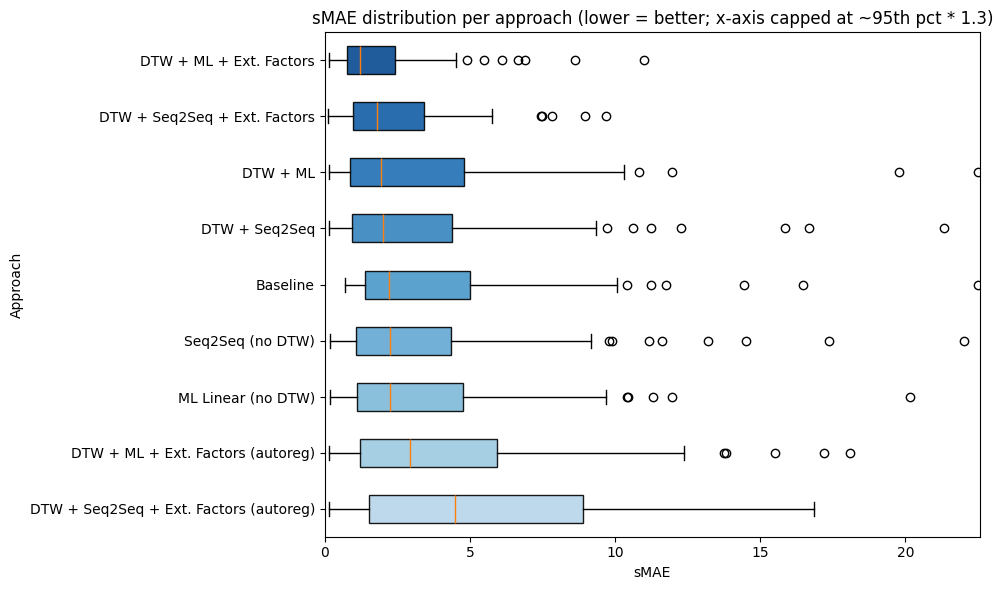

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare the data
df_box = df_energy_results[~df_energy_results['Approach'].isin(EXCLUDE_APPROACHES)].copy()
df_box['Approach'] = df_box['Approach'].replace(APPROACH_LABELS)
df_box = df_box.rename(columns={'sMAE_TEST': 'sMAE'})

# Sort approaches by median DESCENDING (ascending=False).
# Matplotlib horizontal boxplots build from bottom to top, 
# so making the lowest median last puts it at the very top of the chart.
box_order = df_box.groupby('Approach')['sMAE'].median().sort_values(ascending=False).index.tolist()

metric = 'sMAE'
fig, ax = plt.subplots(figsize=(10, 6))

data = [df_box.loc[df_box['Approach'] == a, metric].dropna().values for a in box_order]

# vert=False makes it horizontal (labels on left, values on x-axis)
# patch_artist=True allows us to fill the boxes with color
bplot = ax.boxplot(data, tick_labels=box_order, showfliers=True, vert=False, patch_artist=True)

# Add different scales of blue using the 'Blues' colormap
# We start at 0.3 so the lightest blue isn't completely white/invisible
colors = plt.cm.Blues(np.linspace(0.3, 0.9, len(data)))
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_edgecolor('black') # Added black edges so the boxes stand out better
    patch.set_alpha(0.9)

# Cap the x-axis a bit above the 95th percentile
all_vals = np.concatenate([d for d in data if len(d)])
x_cap = np.percentile(all_vals, 95) * 1.3
ax.set_xlim(0, x_cap)

# Update titles and labels
ax.set_title(f'{metric} distribution per approach (lower = better; x-axis capped at ~95th pct * 1.3)')
ax.set_xlabel(metric)
ax.set_ylabel('Approach')

fig.tight_layout()
fig.savefig(run_dir / 'plots' / 'energy_approach_sMAE_boxplot.png', dpi=130)
plt.show()

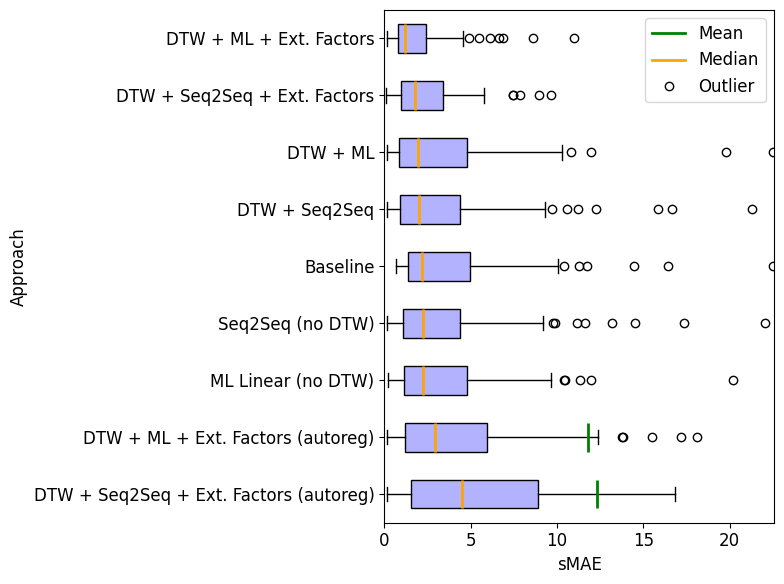

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

# Set global font size to 12 so all text is bigger
plt.rcParams.update({'font.size': 12})

# Prepare the data
df_box = df_energy_results[~df_energy_results['Approach'].isin(EXCLUDE_APPROACHES)].copy()
df_box['Approach'] = df_box['Approach'].replace(APPROACH_LABELS)
df_box = df_box.rename(columns={'sMAE_TEST': 'sMAE'})

# Sort approaches by median DESCENDING (ascending=False).
box_order = df_box.groupby('Approach')['sMAE'].median().sort_values(ascending=False).index.tolist()

metric = 'sMAE'
# Reduced width from 10 to 8 to make it less wide
fig, ax = plt.subplots(figsize=(8, 6))

data = [df_box.loc[df_box['Approach'] == a, metric].dropna().values for a in box_order]

# meanline=True turns the mean marker into a line across the box
# meanprops allows us to customize the color/style of that mean line
bplot = ax.boxplot(
    data, 
    tick_labels=box_order, 
    showfliers=True, 
    showmeans=True, 
    meanline=True, 
    vert=False, 
    patch_artist=True,
    meanprops=dict(color='green', linewidth=2, linestyle='-'),
    medianprops=dict(color='orange', linewidth=2)
)

# Apply the requested blue with alpha=0.1
# We apply alpha only to the facecolor so the black edges remain solid and visible
blue_rgba = mcolors.to_rgba('blue', alpha=0.3)

for patch in bplot['boxes']:
    patch.set_facecolor(blue_rgba)
    patch.set_edgecolor('black')

# Cap the x-axis a bit above the 95th percentile
all_vals = np.concatenate([d for d in data if len(d)])
x_cap = np.percentile(all_vals, 95) * 1.3
ax.set_xlim(0, x_cap)

# Update labels
ax.set_xlabel(metric)
ax.set_ylabel('Approach')

# Create custom legend for Mean, Median, and Outlier
legend_elements = [
    Line2D([0], [0], color='green', lw=2, linestyle='-', label='Mean'),
    Line2D([0], [0], color='orange', lw=2, label='Median'),
    Line2D([0], [0], marker='o', color='w', markeredgecolor='black', markerfacecolor='none', markersize=6, label='Outlier')
]
ax.legend(handles=legend_elements, loc='upper right')


fig.tight_layout()
fig.savefig('visuals/energy_approach_sMAE_boxplot.pdf', dpi=1300)
plt.show()

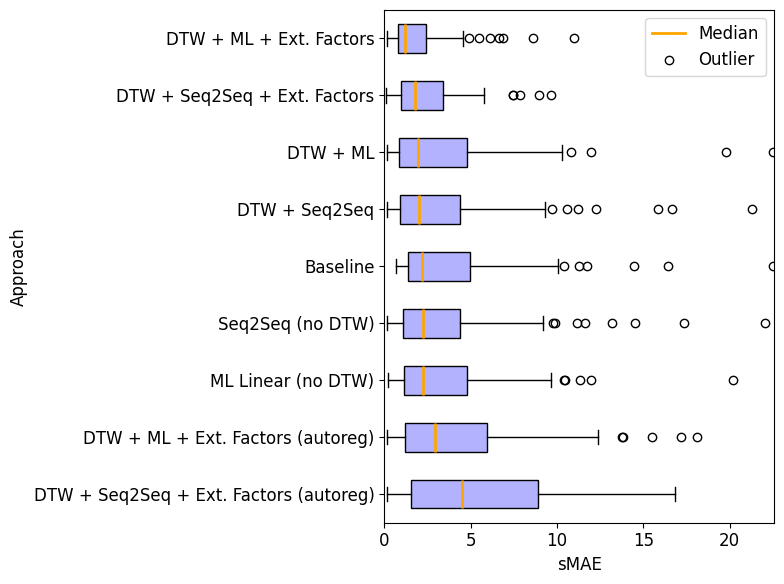

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

# Set global font size to 12 so all text is bigger
plt.rcParams.update({'font.size': 12})

# Prepare the data
df_box = df_energy_results[~df_energy_results['Approach'].isin(EXCLUDE_APPROACHES)].copy()
df_box['Approach'] = df_box['Approach'].replace(APPROACH_LABELS)
df_box = df_box.rename(columns={'sMAE_TEST': 'sMAE'})

# Sort approaches by median DESCENDING (ascending=False).
box_order = df_box.groupby('Approach')['sMAE'].median().sort_values(ascending=False).index.tolist()

metric = 'sMAE'

fig, ax = plt.subplots(figsize=(8, 6))

data = [df_box.loc[df_box['Approach'] == a, metric].dropna().values for a in box_order]

bplot = ax.boxplot(
    data, 
    tick_labels=box_order, 
    showfliers=True, 
    showmeans=False, 
    vert=False, 
    patch_artist=True,
    medianprops=dict(color='orange', linewidth=2)
)

# Apply the requested blue with alpha=0.3
# We apply alpha only to the facecolor so the black edges remain solid and visible
blue_rgba = mcolors.to_rgba('blue', alpha=0.3)

for patch in bplot['boxes']:
    patch.set_facecolor(blue_rgba)
    patch.set_edgecolor('black')

# Cap the x-axis a bit above the 95th percentile
all_vals = np.concatenate([d for d in data if len(d)])
x_cap = np.percentile(all_vals, 95) * 1.3
ax.set_xlim(0, x_cap)

# Update labels
ax.set_xlabel(metric)
ax.set_ylabel('Approach')

# Create custom legend for Median and Outlier
legend_elements = [
    Line2D([0], [0], color='orange', lw=2, label='Median'),
    Line2D([0], [0], marker='o', color='w',
           markeredgecolor='black', markerfacecolor='none',
           markersize=6, label='Outlier')
]
ax.legend(handles=legend_elements, loc='upper right')

fig.tight_layout()
fig.savefig('visuals/energy_approach_sMAE_boxplot.pdf', dpi=1300)
plt.show()

In [15]:
df_energy_results = pd.read_parquet(run_dir / 'summary_train_test.parquet')

#df_energy_results = df_energy_results[['Approach', 'MAE_TEST', 'RMSE_TEST', 'WAPE_TEST']]

df_energy_results

,Process,Sensor,Approach,MAE_TRAIN,RMSE_TRAIN,WAPE_TRAIN,sMAE_TRAIN,sRMSE_TRAIN,MAE_TEST,RMSE_TEST,WAPE_TEST,sMAE_TEST,sRMSE_TEST
0,process_1,autoclave_cooling_water_demand_kW_energy_to_model,Baseline,4.3832,4.3832,62.6126,0.8844,1.0110,4.3832,4.3832,62.9620,0.8848,1.0139
1,process_1,autoclave_cooling_water_demand_kW_energy_to_model,DTW + Ext. Factors + Prev Act,0.3174,1.0151,7.3277,0.1037,0.1459,0.7761,3.1029,9.9947,0.1401,0.2000
2,process_1,autoclave_cooling_water_demand_kW_energy_to_model,DTW + Ext. Factors + Prev Act (autoreg),0.3478,1.1771,7.8229,0.1115,0.1642,1.0111,4.0682,10.4706,0.1422,0.2299
3,process_1,autoclave_cooling_water_demand_kW_energy_to_model,DTW + Seq2Seq,1.7792,2.8984,10.4646,0.1486,0.2233,1.5524,2.5829,10.9377,0.1527,0.2287
4,process_1,autoclave_cooling_water_demand_kW_energy_to_model,DTW + Seq2Seq + Ext. Factors + Prev Act,1.7898,2.6160,8.6489,0.1225,0.1682,2.1700,3.4188,9.2275,0.1298,0.1924
...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,process_5,vor_Vorwärmer_(WT_2)_5s_energy_to_model,DTW + pos,0.5073,0.5812,0.8584,0.7935,0.9697,1.1700,1.2718,1.9936,1.8390,2.0751
997,process_5,vor_Vorwärmer_(WT_2)_5s_energy_to_model,ML DTW + Linear Decode,0.6196,0.6934,1.0481,0.9328,1.1232,1.3675,1.4710,2.3447,1.9828,2.2309
998,process_5,vor_Vorwärmer_(WT_2)_5s_energy_to_model,ML Linear (no DTW),0.3990,0.4709,0.6949,0.6069,0.7500,1.3878,1.4972,2.3397,1.8180,2.0446
999,process_5,vor_Vorwärmer_(WT_2)_5s_energy_to_model,Seq2Seq DTW + Linear Decode,0.6803,0.7499,1.1495,0.9308,1.1047,1.2772,1.3869,2.1695,1.7102,1.9758


In [16]:
df_energy_results['Approach'].unique()

array(['Baseline', 'DTW + Ext. Factors + Prev Act',
       'DTW + Ext. Factors + Prev Act (autoreg)', 'DTW + Seq2Seq',
       'DTW + Seq2Seq + Ext. Factors + Prev Act',
       'DTW + Seq2Seq + Ext. Factors + Prev Act (autoreg)', 'DTW + pos',
       'ML DTW + Linear Decode', 'ML Linear (no DTW)',
       'Seq2Seq DTW + Linear Decode', 'Seq2Seq only (no DTW)'],
      dtype=object)

In [17]:
df_energy_results['Process'].value_counts()

Process
process_5      308
process_4_1    253
process_4_2    253
process_1       77
process_2       55
process_3       55
Name: count, dtype: int64

# Joint Duration + Profile Evaluation

Three tables:
1. **All together** — median sMAE / sRMSE / WAPE per curve approach, aggregated over all processes (best SimMode per process used for durations).
2. **Per simulation mode** — rows = simulation mode sorted by duration WAPE, cols = curve metrics; one table per process × curve approach (requires `curve_joint_duration_eval_per_mode.parquet` from a fresh pipeline run).
3. **Combined** — the process-results table from above extended with curve columns for Baseline and best curve approach; shows that curve quality degrades together with duration quality.

In [18]:
import re as _re

# ── Joint eval ALL TOGETHER — median by Approach across all processes ─────────
_jall_path = run_dir / 'curve_joint_duration_eval_results.parquet'
if not _jall_path.exists():
    print(f'Not found: {_jall_path}  (run the pipeline first)')
else:
    _jall = pd.read_parquet(_jall_path)
    _jm = [m for m in ['sMAE', 'sRMSE', 'WAPE'] if m in _jall.columns]

    # Median per Approach (across all processes, sensors, activities)
    _jall_agg = _jall.groupby('Approach')[_jm].median().round(4)
    _sort_col  = 'WAPE' if 'WAPE' in _jall_agg.columns else _jm[0]
    _jall_agg  = _jall_agg.sort_values(_sort_col)
    display(_jall_agg)

    # Bold the best (lowest) per column
    _jall_str = pd.DataFrame(index=_jall_agg.index, columns=_jall_agg.columns, dtype=object)
    for _c in _jall_agg.columns:
        _best = _jall_agg[_c].dropna().min()
        for _idx in _jall_agg.index:
            _v = _jall_agg.loc[_idx, _c]
            if pd.isna(_v):
                _jall_str.loc[_idx, _c] = ''
            else:
                _fmt = f'{_v:.3f}'
                _jall_str.loc[_idx, _c] = (r'\textbf{' + _fmt + r'}') if abs(_v - _best) < 1e-6 else _fmt

    _jall_str.columns = [
        r'\makecell{sMAE}' if c == 'sMAE' else
        r'\makecell{sRMSE}' if c == 'sRMSE' else
        r'\makecell{WAPE (\%)}' for c in _jall_str.columns
    ]
    _jall_latex = _jall_str.to_latex(
        escape=False,
        column_format='l|' + '|'.join(['c'] * len(_jm)),
        caption=(
            r'Joint duration + profile evaluation: median sMAE / sRMSE / WAPE per curve approach, '
            r'aggregated over all processes and sensors. '
            r'Simulated durations come from the best process model per process (lowest test duration WAPE). '
            r'Lower is better. \textbf{Bold} = best approach.'
        ),
        label=f'tab:joint_eval_all_{EXPERIMENT}',
        position='H',
    )
    print(_jall_latex.replace('_', r'\_'))

Not found: ../results/experiment_943_20260718_095818/curve_joint_duration_eval_results.parquet  (run the pipeline first)


In [19]:
# ── Joint eval PER SIMULATION MODE ───────────────────────────────────────────
# Rows = simulation mode sorted by duration WAPE (best first).
# Columns = sMAE / sRMSE / WAPE for Baseline and best curve approach per process.
# Requires curve_joint_duration_eval_per_mode.parquet (generated by the new pipeline block).

_jpm_path = run_dir / 'curve_joint_duration_eval_per_mode.parquet'
if not _jpm_path.exists():
    print(f'Per-mode joint eval not found at:\n  {_jpm_path}\n'
          'Re-run the pipeline after the modelling.py update to generate this file.')
else:
    _jpm = pd.read_parquet(_jpm_path)
    _jpm_metrics = [m for m in ['sMAE', 'sRMSE', 'WAPE'] if m in _jpm.columns]

    # Duration WAPE per (process, mode) for row ordering
    _pe2 = pd.read_parquet(run_dir / 'process_eval_results.parquet')
    _wc2 = next((c for c in ['test_duration_metrics_activity_duration_wape',
                              'test_duration_metrics_activity_duration_mae']
                 if c in _pe2.columns), None)
    _mwape = {}
    if _wc2:
        for (_pp, _pm), _gg in _pe2.groupby(['process', 'mode']):
            _vv = _gg[_wc2].dropna()
            if not _vv.empty:
                _mwape[(_pp, _pm)] = float(_vv.min())

    # Best curve approach per process (lowest median WAPE_TEST)
    _stp = run_dir / 'summary_train_test.parquet'
    _best_appr_pm = {}
    if _stp.exists():
        _stdf = pd.read_parquet(_stp)
        for _pr, _sg in _stdf.groupby('Process'):
            _pa = _sg.groupby('Approach')['WAPE_TEST'].median()
            if not _pa.empty:
                _best_appr_pm[_pr] = _pa.idxmin()

    def _fmt_sim_mode(m):
        m = str(m)
        if not m.startswith('petri_net_'):
            return m.replace('_', r'\_')
        rest = m[len('petri_net_'):]
        if rest.endswith('_ml_plus_per_act'):
            return rest[:-len('_ml_plus_per_act')].replace('_', r'\_') + r' / ml\_local'
        if rest.endswith('_ml_plus_global'):
            return rest[:-len('_ml_plus_global')].replace('_', r'\_') + r' / ml\_global'
        return rest.replace('_', r'\_') + r' / baseline'

    _pm_latex_parts = []

    for _proc in processes:
        _psub = _jpm[_jpm['Process'] == _proc]
        if _psub.empty:
            continue
        _best_ap = _best_appr_pm.get(_proc, 'Baseline')
        _mode_order = sorted(_psub['SimMode'].unique(),
                             key=lambda m: _mwape.get((_proc, m), 999))

        # One sub-table per approach (Baseline + best)
        for _ap_key, _ap_tag in [('Baseline', 'Baseline'), (_best_ap, 'Best')]:
            _sub_ap = (_psub[_psub['Approach'] == _ap_key]
                       .groupby('SimMode')[_jpm_metrics].median())
            if _sub_ap.empty:
                continue
            _sub_ap = _sub_ap.reindex(_mode_order).round(4)
            _sub_ap.index = [_fmt_sim_mode(m) for m in _sub_ap.index]

            # Bold best (lowest) per column
            _sub_str = pd.DataFrame(index=_sub_ap.index, columns=_sub_ap.columns, dtype=object)
            for _c in _sub_ap.columns:
                _best = _sub_ap[_c].dropna().min()
                for _idx in _sub_ap.index:
                    _v = _sub_ap.loc[_idx, _c]
                    if pd.isna(_v):
                        _sub_str.loc[_idx, _c] = ''
                    else:
                        _fmt2 = f'{_v:.3f}'
                        _sub_str.loc[_idx, _c] = (r'\textbf{' + _fmt2 + r'}') if abs(_v - _best) < 1e-6 else _fmt2

            _proc_ltx = _proc.replace("_", r"\_")
            _ap_key_ltx = _ap_key.replace("_", r"\_")  # if you want LaTeX-escaped underscores

            _sub_str.columns = [
                r'\makecell{sMAE}' if c == 'sMAE' else
                r'\makecell{sRMSE}' if c == 'sRMSE' else
                r'\makecell{WAPE (\%)}' for c in _sub_str.columns
            ]

            _col_fmt = 'l|' + '|'.join(['c'] * len(_jpm_metrics))

            _ltx = _sub_str.to_latex(
                escape=False,
                column_format=_col_fmt,
                caption=(
                    f'Joint eval per simulation mode — {_proc_ltx}, '
                    f'curve approach: {_ap_tag} ({_ap_key_ltx}). '
                    r'Rows sorted by test duration WAPE (best mode first). '
                    r'Lower is better. \textbf{Bold} = best simulation mode.'
                ),
                label=f'tab:joint_pm_{EXPERIMENT}_{_proc}_{_ap_tag.lower()}',
                position='H',
            )

            print(_ltx)
            _pm_latex_parts.append(_ltx)

Per-mode joint eval not found at:
  ../results/experiment_943_20260718_095818/curve_joint_duration_eval_per_mode.parquet
Re-run the pipeline after the modelling.py update to generate this file.


In [20]:
# ── COMBINED TABLE: process metrics + energy curve columns ────────────────────
# Same row structure as the main process-results table above.
# Three extra column groups added for Baseline and best curve approach:
#   sMAE | sRMSE | WAPE (energy)
# Source: curve_joint_duration_eval_per_mode.parquet (per-mode) if available,
#         falling back to curve_joint_duration_eval_results.parquet (best mode only).

_jpm_path  = run_dir / 'curve_joint_duration_eval_per_mode.parquet'
_jall_path = run_dir / 'curve_joint_duration_eval_results.parquet'

if _jpm_path.exists():
    _jsrc_comb = pd.read_parquet(_jpm_path)
    print(f'Using per-mode joint eval ({len(_jsrc_comb)} rows)')
elif _jall_path.exists():
    _jsrc_comb = pd.read_parquet(_jall_path)
    if 'BestMode' in _jsrc_comb.columns and 'SimMode' not in _jsrc_comb.columns:
        _jsrc_comb = _jsrc_comb.rename(columns={'BestMode': 'SimMode'})
    print(f'Per-mode file absent — using best-mode joint eval ({len(_jsrc_comb)} rows). '
          'Rows for non-best modes will show NaN in curve columns.')
else:
    _jsrc_comb = None
    print('No joint eval data found; run the pipeline first.')

if _jsrc_comb is not None:
    _comb_metrics = [m for m in ['sMAE', 'sRMSE', 'WAPE'] if m in _jsrc_comb.columns]

    # Pre-aggregate lookup: (Process, SimMode, Approach) → median curve metrics
    _jlkp = (
        _jsrc_comb
        .groupby(['Process', 'SimMode', 'Approach'])[_comb_metrics]
        .median()
    )

    # Best curve approach per process
    _stp2 = run_dir / 'summary_train_test.parquet'
    _best_ap_comb = {}
    if _stp2.exists():
        _stdf2 = pd.read_parquet(_stp2)
        for _pr2, _sg2 in _stdf2.groupby('Process'):
            _pa2 = _sg2.groupby('Approach')['WAPE_TEST'].median()
            if not _pa2.empty:
                _best_ap_comb[_pr2] = _pa2.idxmin()

    # Map (Process, ProcessModelLabel, DurationPredLabel) → raw SimMode string
    _pe_comb = pd.read_parquet(run_dir / 'process_eval_results.parquet')
    _ba_comb = {}
    for _pc in processes:
        _ba_comb[_pc] = pick_best_algo(_pe_comb[_pe_comb['process'] == _pc], split_prefix)

    def _label_to_simmode(proc, pmodel_lbl, dpred_lbl):
        ba = _ba_comb.get(proc, 'heuristic')
        if 'alpha' in pmodel_lbl:
            return 'petri_net_alpha'
        if 'ml_local'  in dpred_lbl: return f'petri_net_{ba}_ml_plus_per_act'
        if 'ml_global' in dpred_lbl: return f'petri_net_{ba}_ml_plus_global'
        return f'petri_net_{ba}'

    def _curve_vals(proc, sim_mode, approach):
        try:
            row = _jlkp.loc[(proc, sim_mode, approach)]
            return {m: row[m] for m in _comb_metrics}
        except KeyError:
            return {m: float('nan') for m in _comb_metrics}

    # ── Build extended table ──────────────────────────────────────────────────
    _ext_frames = []
    for proc in processes:
        sub_pe = _pe_comb[_pe_comb['process'] == proc]
        ba = _ba_comb[proc]
        best_ap = _best_ap_comb.get(proc, 'Baseline')
        pn = f'{ba} petri net'

        modes_to_show = ['petri_net_alpha', f'petri_net_{ba}',
                         f'petri_net_{ba}_ml_plus_global', f'petri_net_{ba}_ml_plus_per_act']
        sub_pe = sub_pe[sub_pe['mode'].isin(modes_to_show)].copy()
        sub_pe['mode_label'] = sub_pe['mode'].apply(lambda m: make_mode_label(m, ba))

        row_order = [f'{pn} / ml_local', f'{pn} / ml_global',
                     f'{pn} / baseline', 'alpha petri net / baseline']
        sub_pe = sub_pe.set_index('mode_label')[metric_cols]
        sub_pe = sub_pe.reindex([r for r in row_order if r in sub_pe.index])
        sub_pe.columns = [METRIC_LABELS.get(c, c) for c in sub_pe.columns]

        # Append curve metric columns for Baseline and best approach
        for _ck, _ctag in [('Baseline', 'Baseline'), (best_ap, 'Best')]:
            for _m in _comb_metrics:
                sub_pe[f'{_m} ({_ctag})'] = float('nan')

        for row_lbl in sub_pe.index:
            _pml, _dpl = split_mode(row_lbl)
            _sm = _label_to_simmode(proc, _pml, _dpl)
            for _ck, _ctag in [('Baseline', 'Baseline'), (best_ap, 'Best')]:
                _cv = _curve_vals(proc, _sm, _ck)
                for _m, _v in _cv.items():
                    sub_pe.loc[row_lbl, f'{_m} ({_ctag})'] = _v

        _pml_arr, _dpl_arr = zip(*[split_mode(r) for r in sub_pe.index])
        sub_pe.index = pd.MultiIndex.from_arrays(
            [[proc] * len(sub_pe), list(_pml_arr), list(_dpl_arr)],
            names=['Process', 'Process Model', 'Duration Pred.']
        )
        _ext_frames.append(sub_pe)

    ext_table = pd.concat(_ext_frames)
    display(ext_table)

    # ── LaTeX ─────────────────────────────────────────────────────────────────
    _higher_better_keys = {'F1 Score', 'Fitness', 'Precision'}

    def _is_hb_ext(col_label):
        return any(kw in col_label for kw in _higher_better_keys)

    _ext_str = pd.DataFrame(index=ext_table.index, columns=ext_table.columns, dtype=object)
    for proc in processes:
        _pmask = ext_table.index.get_level_values('Process') == proc
        _prows = ext_table[_pmask]
        for col in ext_table.columns:
            _vals = _prows[col].dropna()
            if _vals.empty:
                for idx in _prows.index: _ext_str.loc[idx, col] = ''
                continue
            _best_v = _vals.max() if _is_hb_ext(col) else _vals.min()
            for idx in _prows.index:
                _v2 = ext_table.loc[idx, col]
                if pd.isna(_v2):
                    _ext_str.loc[idx, col] = ''
                else:
                    _f2 = f'{_v2:.3f}'
                    _ext_str.loc[idx, col] = (r'\textbf{' + _f2 + r'}') if abs(_v2 - _best_v) < 1e-6 else _f2

    # Column format: process cols | baseline energy | best energy
    _n_proc   = len(metric_cols)
    _n_curve  = len(_comb_metrics)
    _col_fmt  = 'lll|' + '|'.join(['c'] * _n_proc) + '||' + '|'.join(['c'] * _n_curve) + '||' + '|'.join(['c'] * _n_curve)

    # Column header labels
    def _curve_col_label(m, tag):
        _nm = {'sMAE': r'sMAE', 'sRMSE': r'sRMSE', 'WAPE': r'WAPE\,(\%)'}
        return r'\makecell{' + _nm.get(m, m) + r'\\' + tag + r'}'

    _ext_str.columns = (
        [METRIC_LABELS.get(c, c) for c in metric_cols]
        + [_curve_col_label(m, 'Baseline') for m in _comb_metrics]
        + [_curve_col_label(m, 'Best')     for m in _comb_metrics]
    )

    _best_ap_label = ', '.join(sorted(set(_best_ap_comb.values())))
    _ext_latex = _ext_str.to_latex(
        multicolumn=True,
        multicolumn_format='c',
        multirow=True,
        escape=False,
        column_format=_col_fmt,
        caption=(
            f'Combined process and energy-curve results for experiment {EXPERIMENT} ({SPLIT} evaluation). '
            r'Left block: process model quality metrics (duration error, control-flow, conformance). '
            r'Middle block: energy curve quality using Baseline approach (mean barycenter, no DTW). '
            r'Right block: energy curve quality using the best curve approach per process '
            f'({_best_ap_label.replace("_", r"_")}). '
            r'Curve metrics are evaluated with simulated durations from each row\'s simulation mode '
            r'(shows how curve quality co-degrades with duration quality). '
            r'sMAE / sRMSE standardised by per-sensor std; WAPE is scale-free. '
            r'Lower is better for all metrics except Edge F1 Score, Fitness, Precision (higher = better). '
            r'\textbf{Bold} = best value per process per metric.'
        ),
        label=f'tab:combined_{EXPERIMENT}_{SPLIT}',
        position='H',
    )
    # Clean clines; insert midrules between processes
    _ext_latex = _re.sub(r'\s*\\cline\{[^}]+\}', '', _ext_latex)
    _ext_lines, _ext_new, _ext_cnt = _ext_latex.split('\n'), [], 0
    for _ln in _ext_lines:
        if _re.search(r'\\multirow.*\{process_', _ln):
            if _ext_cnt > 0: _ext_new.append(r'\midrule')
            _ext_cnt += 1
        _ext_new.append(_ln)
    _ext_latex = '\n'.join(_ext_new)
    print(_ext_latex.replace('_', r'\_'))

No joint eval data found; run the pipeline first.


# Energy Distribution Evaluation (case/activity/sensor and case/sensor)

No curve/instance matching -- compares the *distribution* of per-instance energy summary stats (mean/total per activity instance) between the real test set and the simulated log, via Wasserstein (Earth Mover) distance. Lower = simulated distribution closer to real. Reads `energy_distribution_results/<process>/<mode>/*.csv` from the run folder (populated only when `run_energy_modelling=True` for that run).

In [21]:
# -- Load energy-distribution results (case/sensor granularity, total_value) --
energy_dist_dir = run_dir / 'energy_distribution_results'
if not energy_dist_dir.exists():
    print(f'Not found: {energy_dist_dir}\n(run the pipeline with run_energy_modelling=True to generate it)')
    df_energy_dist = pd.DataFrame()
else:
    rows = []
    for proc_dir in sorted(energy_dist_dir.iterdir()):
        if not proc_dir.is_dir():
            continue
        for mode_dir in sorted(proc_dir.iterdir()):
            if not mode_dir.is_dir():
                continue
            csv_path = mode_dir / 'per_case_sensor_total.csv'
            core_path = mode_dir / 'core_metrics.csv'
            if not csv_path.exists():
                continue
            sensor_df = pd.read_csv(csv_path)
            # Recover the real mode string (not the filesystem-safe folder name) from core_metrics.csv
            mode_name = mode_dir.name
            if core_path.exists():
                core_df = pd.read_csv(core_path)
                if 'mode' in core_df.columns and len(core_df) > 0:
                    mode_name = core_df['mode'].iloc[0]
            for _, r in sensor_df.iterrows():
                rows.append({
                    'process': proc_dir.name,
                    'mode': mode_name,
                    'sensor': r['sensor'],
                    'wasserstein': r['wasserstein'],
                    'real_median': r.get('real_median'),
                    'sim_median': r.get('sim_median'),
                })
    df_energy_dist = pd.DataFrame(rows)

print(f'{len(df_energy_dist)} (process, mode, sensor) rows loaded')
df_energy_dist.head(20)

1183 (process, mode, sensor) rows loaded


,process,mode,sensor,wasserstein,real_median,sim_median
0,process_1,petri_net_alpha,autoclave_cooling_water_demand_kW_energy_to_model,25902.530455,26099.747723,4661.524320
1,process_1,petri_net_alpha,autoclave_steam_demand_kW_energy_to_model,50698.438621,52630.938732,8361.273142
2,process_1,petri_net_alpha,bottling_power_kW_energy_to_model,19.610458,21.744043,0.003019
3,process_1,petri_net_alpha,destillation_cooling_demand_kW_energy_to_model,33617.799160,37421.969422,3602.826646
4,process_1,petri_net_alpha,destillation_steam_demand_kW_energy_to_model,32549.913133,35535.592536,2980.131224
5,process_1,petri_net_alpha,individual_packaging_power_kW_energy_to_model,153.142532,139.586530,6.194446
6,process_1,petri_net_alpha,water_supply_power_kW_energy_to_model,5.968717,4.492210,0.000000
7,process_1,petri_net_alpha_ml_plus_global,autoclave_cooling_water_demand_kW_energy_to_model,25902.533036,26099.747723,4661.524320
8,process_1,petri_net_alpha_ml_plus_global,autoclave_steam_demand_kW_energy_to_model,50703.738611,52630.938732,8355.597797
9,process_1,petri_net_alpha_ml_plus_global,bottling_power_kW_energy_to_model,19.610458,21.744043,0.003019


In [22]:
# -- One table per process: rows = sensor, columns = mode (Wasserstein distance) --
# Sensor-as-rows keeps each table narrow (num. modes) regardless of how many
# sensors a process has, instead of one giant sparse table across all processes.
def shorten_sensor(name, max_len=40):
    name = str(name).replace('_energy_to_model', '').replace('_to_model', '')
    return name if len(name) <= max_len else name[:max_len - 1] + '…'

if df_energy_dist.empty:
    print('Nothing to show -- df_energy_dist is empty.')
else:
    df_energy_dist['mode_label'] = df_energy_dist['mode'].map(display_mode)

    for proc in sorted(df_energy_dist['process'].unique()):
        sub = df_energy_dist[df_energy_dist['process'] == proc].copy()
        sub['sensor_short'] = sub['sensor'].map(shorten_sensor)
        pivot = sub.pivot_table(index='sensor_short', columns='mode_label', values='wasserstein', aggfunc='first')

        # Bold the best (lowest) Wasserstein distance per sensor (row)
        str_table = pd.DataFrame(index=pivot.index, columns=pivot.columns, dtype=object)
        for idx in pivot.index:
            vals = pivot.loc[idx].dropna()
            if vals.empty:
                str_table.loc[idx] = ''
                continue
            best_val = vals.min()
            for col in pivot.columns:
                val = pivot.loc[idx, col]
                if pd.isna(val):
                    str_table.loc[idx, col] = ''
                    continue
                fmt = f'{val:.2f}'
                str_table.loc[idx, col] = (r'\textbf{' + fmt + r'}') if abs(val - best_val) < 1e-6 else fmt

        n_modes = len(pivot.columns)
        col_format = 'l|' + '|'.join(['c'] * n_modes)
        latex = str_table.to_latex(
            escape=False,
            column_format=col_format,
            caption=(
                f'Energy-distribution evaluation for {proc}, experiment {EXPERIMENT} ({SPLIT} evaluation). '
                r'Wasserstein (Earth Mover) distance between the per-case total energy distribution '
                r'(real vs.\ simulated), per sensor --- no curve/instance matching. '
                r'Lower is better. \textbf{Bold} = best mode per sensor.'
            ),
            label=f'tab:energy_dist_{EXPERIMENT}_{SPLIT}_{proc}',
            position='H',
        )
        print(f'% === {proc}: {pivot.shape[0]} sensors x {pivot.shape[1]} modes ===')
        print(latex.replace('_', r'\_'))
        print()

    display(df_energy_dist.pivot_table(index=['process', 'sensor'], columns='mode_label', values='wasserstein', aggfunc='first').round(2))

% === process_1: 7 sensors x 13 modes ===
\begin{table}[H]
\caption{Energy-distribution evaluation for process\_1, experiment 943 (test evaluation). Wasserstein (Earth Mover) distance between the per-case total energy distribution (real vs.\ simulated), per sensor --- no curve/instance matching. Lower is better. \textbf{Bold} = best mode per sensor.}
\label{tab:energy\_dist\_943\_test\_process\_1}
\begin{tabular}{l|c|c|c|c|c|c|c|c|c|c|c|c|c}
\toprule
mode\_label & alpha / baseline & alpha / ml\_global & alpha / ml\_local & budget / baseline & budget / ml\_global & budget / ml\_local & heuristic / baseline & heuristic / ml\_global & heuristic / ml\_local & wip\_aware / baseline & wip\_aware / ml\_global & wip\_aware / ml\_local & wip\_branching\_aware / baseline \\
sensor\_short &  &  &  &  &  &  &  &  &  &  &  &  &  \\
\midrule
autoclave\_cooling\_water\_demand\_kW & 25902.53 & 25902.53 & 25902.53 & 27060.83 & 26230.17 & 27320.21 & 25461.24 & 25461.24 & 25461.24 & 25461.24 & 25461.24 &

mode_label                                                    alpha / baseline  \
process   sensor                                                                 
process_1 autoclave_cooling_water_demand_kW_energy_to_model           25902.53   
          autoclave_steam_demand_kW_energy_to_model                   50698.44   
          bottling_power_kW_energy_to_model                              19.61   
          destillation_cooling_demand_kW_energy_to_model              33617.80   
          destillation_steam_demand_kW_energy_to_model                32549.91   
...                                                                        ...   
process_5 temp_nach_Kuehlturmkuehler_(WT6)_5s_energy_to_m...           9467.88   
          temp_nach_WR2,_vor_Druckerhoehungspumpe_(WT4)_5...          43637.00   
          temp_nach_WR2_(WT2)_5s_energy_to_model                       9800.57   
          temp_vor_Vorwärmer_(WT_2)_1h_energy_to_model                28775.65   
          vor_Vorwärmer_(WT_2)_5s_energy_to_model                     28854.09   

mode_label                                                    alpha / ml_global  \
process   sensor                                                                  
process_1 autoclave_cooling_water_demand_kW_energy_to_model            25902.53   
          autoclave_steam_demand_kW_energy_to_model                    50703.74   
          bottling_power_kW_energy_to_model                               19.61   
          destillation_cooling_demand_kW_energy_to_model               33721.51   
          destillation_steam_demand_kW_energy_to_model                 32659.73   
...                                                                         ...   
process_5 temp_nach_Kuehlturmkuehler_(WT6)_5s_energy_to_m...            9532.65   
          temp_nach_WR2,_vor_Druckerhoehungspumpe_(WT4)_5...           43915.53   
          temp_nach_WR2_(WT2)_5s_energy_to_model                        9872.01   
          temp_vor_Vorwärmer_(WT_2)_1h_energy_to_model                 28962.94   
          vor_Vorwärmer_(WT_2)_5s_energy_to_model                      29041.67   

mode_label                                                    alpha / ml_local  \
process   sensor                                                                 
process_1 autoclave_cooling_water_demand_kW_energy_to_model           25902.53   
          autoclave_steam_demand_kW_energy_to_model                   50700.09   
          bottling_power_kW_energy_to_model                              19.61   
          destillation_cooling_demand_kW_energy_to_model              33544.23   
          destillation_steam_demand_kW_energy_to_model                32471.55   
...                                                                        ...   
process_5 temp_nach_Kuehlturmkuehler_(WT6)_5s_energy_to_m...           9487.98   
          temp_nach_WR2,_vor_Druckerhoehungspumpe_(WT4)_5...          43722.51   
          temp_nach_WR2_(WT2)_5s_energy_to_model                       9822.10   
          temp_vor_Vorwärmer_(WT_2)_1h_energy_to_model                28832.00   
          vor_Vorwärmer_(WT_2)_5s_energy_to_model                     28912.07   

mode_label                                                    budget / baseline  \
process   sensor                                                                  
process_1 autoclave_cooling_water_demand_kW_energy_to_model            27060.83   
          autoclave_steam_demand_kW_energy_to_model                    53864.98   
          bottling_power_kW_energy_to_model                               19.61   
          destillation_cooling_demand_kW_energy_to_model               33558.64   
          destillation_steam_demand_kW_energy_to_model                 32487.26   
...                                                                         ...   
process_5 temp_nach_Kuehlturmkuehler_(WT6)_5s_energy_to_m...            7583.68   
          temp_nach_WR2,_vor_Druckerhoe

## Aggregated ranking (one number per process x method)

Rolls the per-sensor Wasserstein distances up to a single **scale-free** number per (process, mode): `relative_wasserstein = wasserstein / real_median`, so a kg/h sensor and a °C sensor can be averaged fairly. Median over sensors per process, then median over processes for `Overall`. Rows sorted best-to-worst.

In [23]:
# -- Aggregate: one relative-Wasserstein number per (process, mode) ----------
if df_energy_dist.empty:
    print('Nothing to show -- df_energy_dist is empty.')
else:
    df_energy_dist['relative_wasserstein'] = (
        df_energy_dist['wasserstein'] / df_energy_dist['real_median'].abs().replace(0, float('nan'))
    )
    rank_agg = df_energy_dist.groupby(['process', 'mode_label'])['relative_wasserstein'].median().reset_index()
    rank_pivot = rank_agg.pivot(index='mode_label', columns='process', values='relative_wasserstein')
    rank_pivot['Overall'] = rank_pivot.median(axis=1)
    rank_pivot = rank_pivot.sort_values('Overall')

    str_table = pd.DataFrame(index=rank_pivot.index, columns=rank_pivot.columns, dtype=object)
    for col in rank_pivot.columns:
        vals = rank_pivot[col].dropna()
        if vals.empty:
            str_table[col] = ''
            continue
        best_val = vals.min()
        for idx in rank_pivot.index:
            val = rank_pivot.loc[idx, col]
            if pd.isna(val):
                str_table.loc[idx, col] = ''
                continue
            fmt = f'{val:.3f}'
            str_table.loc[idx, col] = (r'\textbf{' + fmt + r'}') if abs(val - best_val) < 1e-6 else fmt

    n_cols = len(rank_pivot.columns)
    col_format = 'l|' + '|'.join(['c'] * (n_cols - 1)) + '|c'
    rank_latex = str_table.to_latex(
        escape=False, column_format=col_format,
        caption=(
            f'Aggregated energy-distribution ranking, experiment {EXPERIMENT} ({SPLIT} evaluation). '
            r'Median relative Wasserstein distance (Wasserstein / real median) over sensors per process, '
            r'then median over processes for Overall. '
            r'Lower is better. Rows sorted best-to-worst by Overall. \textbf{Bold} = best mode per column.'
        ),
        label=f'tab:energy_dist_ranking_{EXPERIMENT}_{SPLIT}',
        position='H',
    )
    print(rank_latex.replace('_', r'\_'))
    display(rank_pivot.round(3))

\begin{table}[H]
\caption{Aggregated energy-distribution ranking, experiment 943 (test evaluation). Median relative Wasserstein distance (Wasserstein / real median) over sensors per process, then median over processes for Overall. Lower is better. Rows sorted best-to-worst by Overall. \textbf{Bold} = best mode per column.}
\label{tab:energy\_dist\_ranking\_943\_test}
\begin{tabular}{l|c|c|c|c|c|c|c}
\toprule
process & process\_1 & process\_2 & process\_3 & process\_4\_1 & process\_4\_2 & process\_5 & Overall \\
mode\_label &  &  &  &  &  &  &  \\
\midrule
budget / ml\_local & 1.025 & 0.710 & 1.598 & 0.864 & 0.920 & 0.851 & \textbf{0.892} \\
budget / ml\_global & 1.005 & \textbf{0.709} & 1.600 & 0.864 & 0.920 & \textbf{0.844} & 0.892 \\
wip\_aware / baseline & 0.917 & 0.834 & \textbf{1.551} & 0.891 & 0.907 & 1.167 & 0.912 \\
heuristic / baseline & 0.916 & 0.834 & 1.653 & 0.885 & 0.912 & 1.157 & 0.914 \\
wip\_aware / ml\_local & \textbf{0.912} & 0.834 & 1.664 & 0.899 & 0.931 & 1.186 & 0.

process,process_1,process_2,process_3,process_4_1,process_4_2,process_5,Overall
mode_label,,,,,,,
budget / ml_local,1.025,0.710,1.598,0.864,0.920,0.851,0.892
budget / ml_global,1.005,0.709,1.600,0.864,0.920,0.844,0.892
wip_aware / baseline,0.917,0.834,1.551,0.891,0.907,1.167,0.912
heuristic / baseline,0.916,0.834,1.653,0.885,0.912,1.157,0.914
wip_aware / ml_local,0.912,0.834,1.664,0.899,0.931,1.186,0.922
heuristic / ml_local,0.914,0.834,1.664,0.899,0.931,1.186,0.922
wip_aware / ml_global,0.919,0.834,1.662,0.900,0.932,1.187,0.926
heuristic / ml_global,0.919,0.834,1.662,0.900,0.933,1.187,0.926
budget / baseline,1.023,0.784,1.609,0.848,0.903,1.023,0.963


NameError: name 'sns' is not defined

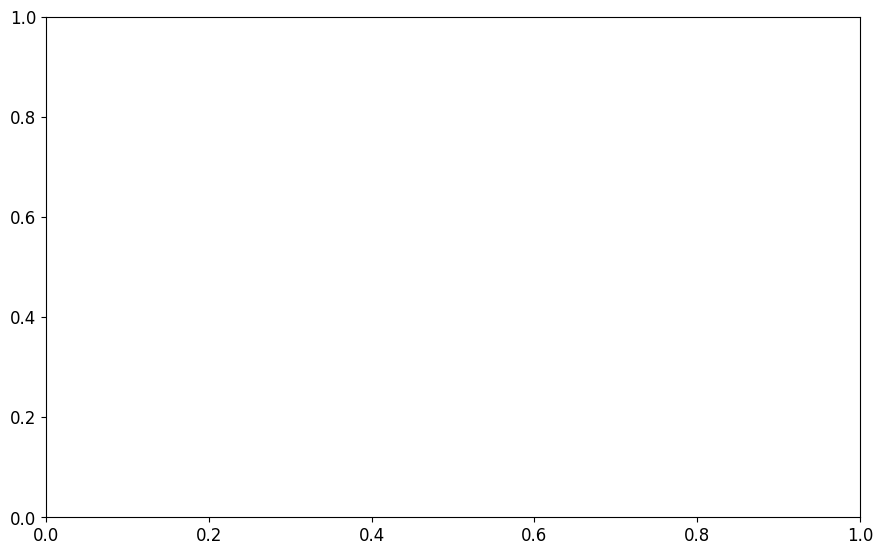

In [24]:
# -- Ranking heatmap: mode (rows, sorted best-to-worst) x process ------------
if df_energy_dist.empty:
    print('Nothing to show -- df_energy_dist is empty.')
else:
    fig, ax = plt.subplots(figsize=(max(8, 1.5 * len(rank_pivot.columns)), max(3, 0.5 * len(rank_pivot))))
    sns.heatmap(
        rank_pivot, annot=rank_pivot.round(2), fmt='', cmap='RdYlGn_r',
        linewidths=0.5, linecolor='white',
        cbar_kws={'label': 'relative Wasserstein dist.\n(lower = better)'},
        ax=ax,
    )
    ax.set_title(f'Aggregated energy-distribution ranking (experiment {EXPERIMENT}, {SPLIT})\n'
                 'rows sorted best (top) to worst (bottom) by Overall', pad=14)
    ax.set_xlabel('process'); ax.set_ylabel('mode')
    plt.setp(ax.get_yticklabels(), rotation=0)
    fig.tight_layout()
    fig.savefig(run_dir / 'plots' / 'energy_dist_ranking_heatmap.png', dpi=130)
    plt.show()

## Does process-model quality predict energy-profile quality?

Merges the existing process-fidelity metric (`test_overall_error`, from `process_eval_results.parquet`) with the energy-distribution ranking built above, one point per (process, mode).

**Important caveat, not swept under the rug**: several (process, mode) pairs produce a *numerically identical* simulated schedule as another mode in the same process -- e.g. `wip_aware_ml_plus_global` and `heuristic_ml_plus_global` are mathematically guaranteed to collapse to the same result whenever `MINING_ALGORITHM='heuristic'`, since ML+ duration prediction doesn't use wip/ro at all, and `wip_aware` reuses `MINING_ALGORITHM`'s own net. Including duplicate, non-independent observations inflates the sample size without adding real information, and pulls the correlation toward zero. The cell below detects these duplicates (by comparing each mode's predicted `sim_median` signature per process) and reports the correlation **with and without them** -- report the 'clean' number, not the naive one.

In [ ]:
from scipy.stats import spearmanr

# -- process-model quality (already computed earlier as `df`) ---------------
proc_quality = df[['process', 'mode_label', 'test_overall_error']].dropna()

# -- detect duplicate-schedule (process, mode) pairs --------------------------
sig_rows = []
for proc_dir in sorted(energy_dist_dir.iterdir()):
    if not proc_dir.is_dir():
        continue
    for mode_dir in sorted(proc_dir.iterdir()):
        if not mode_dir.is_dir():
            continue
        csv_path = mode_dir / 'per_case_sensor_total.csv'
        core_path = mode_dir / 'core_metrics.csv'
        if not csv_path.exists():
            continue
        sensor_df = pd.read_csv(csv_path)
        mode_name = mode_dir.name
        if core_path.exists():
            core_df = pd.read_csv(core_path)
            if 'mode' in core_df.columns and len(core_df) > 0:
                mode_name = core_df['mode'].iloc[0]
        sig_rows.append({
            'process': proc_dir.name, 'mode': mode_name,
            'sig': tuple(sensor_df.sort_values('sensor')['sim_median'].round(3)),
        })
sig_df = pd.DataFrame(sig_rows)
sig_df['is_duplicate'] = sig_df.duplicated(subset=['process', 'sig'], keep=False)
sig_df['mode_label'] = sig_df['mode'].map(display_mode)

# -- energy-profile quality (reuse from the aggregated-ranking cell) ---------
corr_merged = proc_quality.merge(rank_agg, on=['process', 'mode_label'], how='inner')
corr_merged = corr_merged.merge(
    sig_df[['process', 'mode_label', 'is_duplicate']], on=['process', 'mode_label'], how='left'
)
clean = corr_merged[~corr_merged['is_duplicate']]

rho_all, p_all = spearmanr(corr_merged['test_overall_error'], corr_merged['relative_wasserstein'])
rho_clean, p_clean = spearmanr(clean['test_overall_error'], clean['relative_wasserstein'])
print(f'All {len(corr_merged)} pairs (naive):        rho={rho_all:+.3f}  p={p_all:.4f}')
print(f'Clean {len(clean)} pairs (duplicates removed): rho={rho_clean:+.3f}  p={p_clean:.4f}')
print(f'\n{corr_merged["is_duplicate"].sum()} of {len(corr_merged)} pairs flagged as duplicate schedules.')

# -- scatter plot --------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6))
processes_c = sorted(corr_merged['process'].unique())
colors_c = plt.cm.tab10(np.linspace(0, 1, len(processes_c)))
proc_color = dict(zip(processes_c, colors_c))
for _, r in corr_merged.iterrows():
    marker = 'x' if r['is_duplicate'] else 'o'
    ax.scatter(r['test_overall_error'], r['relative_wasserstein'],
               color=proc_color[r['process']], marker=marker, s=70,
               edgecolors=('black' if not r['is_duplicate'] else None), linewidths=0.6, alpha=0.85)
for proc in processes_c:
    ax.scatter([], [], color=proc_color[proc], label=proc, s=60)
ax.scatter([], [], color='gray', marker='o', label='distinct schedule', s=60)
ax.scatter([], [], color='gray', marker='x', label='duplicate schedule\n(excluded from "clean" fit)', s=60)
ax.set_xlabel('process-model error (test_overall_error, lower=better)')
ax.set_ylabel('energy-profile error (relative Wasserstein, lower=better)')
ax.set_title('Process-model quality vs energy-profile quality\n'
             f'all pairs: rho={rho_all:+.2f} (p={p_all:.2f})   |   '
             f'clean pairs only: rho={rho_clean:+.2f} (p={p_clean:.2f})')
ax.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1.02, 1))
fig.tight_layout()
fig.savefig(run_dir / 'plots' / 'energy_dist_correlation_scatter.png', dpi=130)
plt.show()

### The raw check, side by side

Full table behind the correlation above: one row per (process, mode), process-quality score, energy-quality score, and whether that row's simulated schedule is a duplicate of another mode's in the same process (both scores lower = better). Look at `process_1`: six rows share the exact same `energy_error` (0.9516...) despite different `process_error` values -- that's six "different modes" that produced the literal same simulated schedule, which is why they're excluded from the clean check.

In [ ]:
# -- Full side-by-side table + both checks -----------------------------------
display_table = corr_merged.rename(
    columns={'test_overall_error': 'process_error', 'relative_wasserstein': 'energy_error'}
).sort_values(['process', 'energy_error'])[
    ['process', 'mode_label', 'process_error', 'energy_error', 'is_duplicate']
]
print('=== FULL TABLE: every (process, mode) pair used in the check ===')
display(display_table)

print(f'\n=== CHECK 1: naive, all {len(corr_merged)} pairs (duplicates included) ===')
print(f'rho={rho_all:+.3f}  p={p_all:.4f}   -> {"significant" if p_all < 0.05 else "NOT significant"}')

print(f'\n=== CHECK 2: clean, {len(clean)} pairs ({corr_merged["is_duplicate"].sum()} duplicates removed) ===')
print(f'rho={rho_clean:+.3f}  p={p_clean:.4f}   -> {"significant" if p_clean < 0.05 else "NOT significant"}')

print(f'\n=== The {corr_merged["is_duplicate"].sum()} duplicate rows removed for Check 2 ===')
display(
    corr_merged[corr_merged['is_duplicate']]
    .rename(columns={'test_overall_error': 'process_error', 'relative_wasserstein': 'energy_error'})
    .sort_values(['process', 'mode_label'])[['process', 'mode_label', 'process_error', 'energy_error']]
)

## Same check, but per (process, mode, sensor) -- not aggregated per process

The scatter above collapsed every sensor within a (process, mode) down to one median point (40 dots, 26 after removing duplicates). This version keeps every sensor as its own point instead -- ~536 dots across all processes together, plotted on one shared scatter (log scale on the y-axis, since relative Wasserstein distance spans several orders of magnitude across sensors). Same duplicate-schedule exclusion as before, same process_error x-axis. More points, more noise visible, but also much higher statistical power -- the correlation holds (and is stronger) even without removing duplicates.

In [ ]:
# -- Per (process, mode, sensor): no aggregation, all processes on one plot --
instance_merged = df_energy_dist.merge(proc_quality, on=['process', 'mode_label'], how='inner')
instance_merged = instance_merged.merge(
    sig_df[['process', 'mode_label', 'is_duplicate']], on=['process', 'mode_label'], how='left'
)
instance_merged = instance_merged.dropna(subset=['relative_wasserstein', 'test_overall_error'])
instance_clean = instance_merged[~instance_merged['is_duplicate']]

rho_i_all, p_i_all = spearmanr(instance_merged['test_overall_error'], instance_merged['relative_wasserstein'])
rho_i_clean, p_i_clean = spearmanr(instance_clean['test_overall_error'], instance_clean['relative_wasserstein'])
print(f'All (process, mode, sensor) points: n={len(instance_merged)}  rho={rho_i_all:+.3f}  p={p_i_all:.4g}')
print(f'Clean (non-duplicate) points:       n={len(instance_clean)}  rho={rho_i_clean:+.3f}  p={p_i_clean:.4g}')

fig, ax = plt.subplots(figsize=(9, 7))
processes_i = sorted(instance_merged['process'].unique())
colors_i = plt.cm.tab10(np.linspace(0, 1, len(processes_i)))
proc_color_i = dict(zip(processes_i, colors_i))
for _, r in instance_merged.iterrows():
    marker = 'x' if r['is_duplicate'] else 'o'
    ax.scatter(r['test_overall_error'], r['relative_wasserstein'],
               color=proc_color_i[r['process']], marker=marker, s=28,
               edgecolors=('black' if not r['is_duplicate'] else None), linewidths=0.3, alpha=0.6)
for proc in processes_i:
    ax.scatter([], [], color=proc_color_i[proc], label=proc, s=50)
ax.scatter([], [], color='gray', marker='o', label='distinct schedule', s=50)
ax.scatter([], [], color='gray', marker='x', label='duplicate schedule (excluded)', s=50)
ax.set_yscale('log')
ax.set_xlabel('process-model error (test_overall_error, lower=better)')
ax.set_ylabel('energy-profile error per sensor (relative Wasserstein, log scale, lower=better)')
ax.set_title('Process-model quality vs energy-profile quality -- per (process, mode, sensor)\n'
             f'all points: rho={rho_i_all:+.2f} (p={p_i_all:.1g}, n={len(instance_merged)})   |   '
             f'clean: rho={rho_i_clean:+.2f} (p={p_i_clean:.1g}, n={len(instance_clean)})')
ax.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1.02, 1))
fig.tight_layout()
fig.savefig(run_dir / 'plots' / 'energy_dist_correlation_scatter_per_sensor.png', dpi=130)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, linregress

# -- Per (process, mode, sensor): no aggregation, all processes on one plot --
instance_merged = df_energy_dist.merge(proc_quality, on=['process', 'mode_label'], how='inner')
instance_merged = instance_merged.merge(
    sig_df[['process', 'mode_label', 'is_duplicate']], on=['process', 'mode_label'], how='left'
)
instance_merged = instance_merged.dropna(subset=['relative_wasserstein', 'test_overall_error'])
instance_clean = instance_merged[~instance_merged['is_duplicate']]

rho_i_all, p_i_all = spearmanr(instance_merged['test_overall_error'], instance_merged['relative_wasserstein'])
rho_i_clean, p_i_clean = spearmanr(instance_clean['test_overall_error'], instance_clean['relative_wasserstein'])
print(f'All (process, mode, sensor) points: n={len(instance_merged)}  rho={rho_i_all:+.3f}  p={p_i_all:.4g}')
print(f'Clean (non-duplicate) points:       n={len(instance_clean)}  rho={rho_i_clean:+.3f}  p={p_i_clean:.4g}')

# --- Calculate Linear Regression over ALL points ---
x_all = instance_merged['test_overall_error']
y_all = instance_merged['relative_wasserstein']
slope, intercept, r_value, p_value, std_err = linregress(x_all, y_all)

# Generate points for the regression line
x_line = np.linspace(x_all.min(), x_all.max(), 100)
y_line = slope * x_line + intercept

fig, ax = plt.subplots(figsize=(9, 7))
processes_i = sorted(instance_merged['process'].unique())
colors_i = plt.cm.tab10(np.linspace(0, 1, len(processes_i)))
proc_color_i = dict(zip(processes_i, colors_i))

for _, r in instance_merged.iterrows():
    marker = 'x' if r['is_duplicate'] else 'o'
    ax.scatter(r['test_overall_error'], r['relative_wasserstein'],
               color=proc_color_i[r['process']], marker=marker, s=28,
               edgecolors=('black' if not r['is_duplicate'] else None), 
               linewidths=0.3, alpha=0.6, zorder=2)

# --- Plot the Linear Regression Line ---
ax.plot(x_line, y_line, color='red', linestyle='--', linewidth=2, zorder=10, 
        label=f'Lin. Reg (all points)\ny={slope:.2e}x + {intercept:.2f}')

for proc in processes_i:
    ax.scatter([], [], color=proc_color_i[proc], label=proc, s=50)
ax.scatter([], [], color='gray', marker='o', label='distinct schedule', s=50)
ax.scatter([], [], color='gray', marker='x', label='duplicate schedule (excluded)', s=50)

# Log scale removed entirely
ax.set_xlabel('process-model error (test_overall_error, lower=better)')
ax.set_ylabel('energy-profile error per sensor (relative Wasserstein, lower=better)')
ax.set_title('Process-model quality vs energy-profile quality -- per (process, mode, sensor)\n'
             f'all points: rho={rho_i_all:+.2f} (p={p_i_all:.1g}, n={len(instance_merged)})   |   '
             f'clean: rho={rho_i_clean:+.2f} (p={p_i_clean:.1g}, n={len(instance_clean)})')

ax.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1.02, 1))
fig.tight_layout()
fig.savefig(run_dir / 'plots' / 'energy_dist_correlation_scatter_per_sensor.png', dpi=130)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, linregress

# -- Per (process, mode, sensor): no aggregation, all processes on one plot --
instance_merged = df_energy_dist.merge(proc_quality, on=['process', 'mode_label'], how='inner')
instance_merged = instance_merged.merge(
    sig_df[['process', 'mode_label', 'is_duplicate']], on=['process', 'mode_label'], how='left'
)
instance_merged = instance_merged.dropna(subset=['relative_wasserstein', 'test_overall_error'])

# --- FILTER: Remove points above 20 for both axes ---
instance_merged = instance_merged[
    (instance_merged['test_overall_error'] <= 20) & 
    (instance_merged['relative_wasserstein'] <= 20)
]

instance_clean = instance_merged[~instance_merged['is_duplicate']]

rho_i_all, p_i_all = spearmanr(instance_merged['test_overall_error'], instance_merged['relative_wasserstein'])
rho_i_clean, p_i_clean = spearmanr(instance_clean['test_overall_error'], instance_clean['relative_wasserstein'])
print(f'All (process, mode, sensor) points: n={len(instance_merged)}  rho={rho_i_all:+.3f}  p={p_i_all:.4g}')
print(f'Clean (non-duplicate) points:       n={len(instance_clean)}  rho={rho_i_clean:+.3f}  p={p_i_clean:.4g}')

# --- Calculate Linear Regression over ALL points ---
x_all = instance_merged['test_overall_error']
y_all = instance_merged['relative_wasserstein']
slope, intercept, r_value, p_value, std_err = linregress(x_all, y_all)

# Generate points for the regression line
x_line = np.linspace(x_all.min(), x_all.max(), 100)
y_line = slope * x_line + intercept

fig, ax = plt.subplots(figsize=(9, 7))
processes_i = sorted(instance_merged['process'].unique())
colors_i = plt.cm.tab10(np.linspace(0, 1, len(processes_i)))
proc_color_i = dict(zip(processes_i, colors_i))

for _, r in instance_merged.iterrows():
    marker = 'x' if r['is_duplicate'] else 'o'
    ax.scatter(r['test_overall_error'], r['relative_wasserstein'],
               color=proc_color_i[r['process']], marker=marker, s=28,
               edgecolors=('black' if not r['is_duplicate'] else None), 
               linewidths=0.3, alpha=0.6, zorder=2)

# --- Plot the Linear Regression Line ---
ax.plot(x_line, y_line, color='red', linestyle='--', linewidth=2, zorder=10, 
        label=f'Lin. Reg (all points)\ny={slope:.2e}x + {intercept:.2f}')

for proc in processes_i:
    ax.scatter([], [], color=proc_color_i[proc], label=proc, s=50)
ax.scatter([], [], color='gray', marker='o', label='distinct schedule', s=50)
ax.scatter([], [], color='gray', marker='x', label='duplicate schedule (excluded)', s=50)

# Log scale removed entirely
ax.set_xlabel('process-model error (test_overall_error, lower=better)')
ax.set_ylabel('energy-profile error per sensor (relative Wasserstein, lower=better)')
ax.set_title('Process-model quality vs energy-profile quality -- per (process, mode, sensor)\n'
             f'all points: rho={rho_i_all:+.2f} (p={p_i_all:.1g}, n={len(instance_merged)})   |   '
             f'clean: rho={rho_i_clean:+.2f} (p={p_i_clean:.1g}, n={len(instance_clean)})')

ax.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1.02, 1))
fig.tight_layout()
fig.savefig(run_dir / 'plots' / 'energy_dist_correlation_scatter_per_sensor.png', dpi=130)
plt.show()

# Complete-Curve Evaluation (per-case, shift-tolerant Wasserstein)

New, additional evaluation -- does not replace anything above. For every real test case, matched to its same-`case_id` counterpart in each simulated log, this:

1. Concatenates the case's real per-activity sensor curves (in real time order) into one complete real profile.
2. Predicts each of that case's activities' curves with the trained `baseline` (median/barycenter per activity) and `exog_prev_activity` ("DTW + Ext. Factors + Prev Act", the strongest curve-fitting approach) pipelines, using the simulated log's own activities/durations, and concatenates them into one complete simulated profile for the same case.
3. Compares the two complete profiles with two Wasserstein (Earth Mover's) distances along orthogonal axes, instead of a single mean/total summary stat (which a trivial "predict the mean everywhere" model could win without getting anything useful right):
   - **W1 (time)** -- curve values as weights, case-relative time as the transport axis. Answers "is the timing/shape right." Order-sensitive; blind to overall magnitude (a right-shaped-but-30%-too-high curve still scores well here, since W1 normalises each curve to the same total mass before comparing).
   - **W1 (value)** -- raw curve values as the transport axis, unweighted. Answers "is the distribution of magnitudes right" -- catches scale *and* spread/variance errors. Order-blind (doesn't know *when* a value occurred), so it's exactly complementary to W1 (time). Works uniformly for intensive sensors (temperature, concentration) and extensive ones (power, flow), since nothing is summed or averaged before comparing.

A model can't fool both at once: winning W1 (value) by predicting a flat mean loses badly on W1 (time), since all its mass then sits in the wrong place in time.

Source: `complete_curve_eval_results/<process>/<mode>/complete_curve_summary[_exog_prev_activity].csv`, populated per (process, mode, approach) when the pipeline runs with `run_energy_modelling=True`. If it's missing, re-run the pipeline after this modelling.py update.


In [ ]:
# -- Load complete-curve evaluation results (per-case, shift-tolerant Wasserstein) --
# Discovers every approach that has a complete_curve_summary*.csv in a mode folder
# (complete-curve eval runs against every trained non-seq2seq approach, not just
# baseline + exog_prev_activity -- see modelling.py's COMPLETE-CURVE EVAL block),
# rather than assuming a fixed pair.
#
# Two Wasserstein distances along two orthogonal axes, not a mean/total summary
# stat: wasserstein_time (values as weights, time as the transport axis -- is the
# timing/shape right) and wasserstein_value (raw values as the transport axis,
# unweighted -- is the distribution of magnitudes right). Neither can be gamed by
# a trivial "predict the mean everywhere" model: that scores badly on
# wasserstein_time (all its mass sits in the wrong place in time) and on
# wasserstein_value (zero variance vs. the real curve's actual spread). Works
# uniformly for intensive (temperature) and extensive (power, flow) sensors alike,
# since nothing is summed or averaged before comparing.
complete_curve_dir = run_dir / 'complete_curve_eval_results'

if not complete_curve_dir.exists():
    print(f'Not found: {complete_curve_dir}\n(run the pipeline with run_energy_modelling=True to generate it)')
    df_complete_curve = pd.DataFrame()
else:
    rows = []
    for proc_dir in sorted(complete_curve_dir.iterdir()):
        if not proc_dir.is_dir():
            continue
        for mode_dir in sorted(proc_dir.iterdir()):
            if not mode_dir.is_dir():
                continue
            for summary_path in sorted(mode_dir.glob('complete_curve_summary*.csv')):
                # 'complete_curve_summary.csv' -> baseline; '..._<approach>.csv' -> <approach>
                _stem = summary_path.stem  # 'complete_curve_summary' or 'complete_curve_summary_<approach>'
                _suffix = _stem[len('complete_curve_summary'):]
                approach = _suffix[1:] if _suffix.startswith('_') else 'baseline'

                summ = pd.read_csv(summary_path)
                if summ.empty:
                    continue
                mode_name = summ['mode'].iloc[0] if 'mode' in summ.columns else mode_dir.name
                for _, r in summ.iterrows():
                    rows.append({
                        'process':                   proc_dir.name,
                        'mode':                      mode_name,
                        'approach':                  approach,
                        'sensor':                    r['sensor'],
                        'wasserstein_time_median':   r['wasserstein_time_median'],
                        'wasserstein_value_median':  r.get('wasserstein_value_median'),
                        'n_cases':                   r['n_cases'],
                    })
    df_complete_curve = pd.DataFrame(rows)

print(f'{len(df_complete_curve)} (process, mode, approach, sensor) rows loaded')
if not df_complete_curve.empty:
    print(f'Approaches found: {sorted(df_complete_curve["approach"].unique())}')
df_complete_curve.head(20)


In [ ]:
# -- Scale-free versions of the two complete-curve Wasserstein metrics --
# wasserstein_time_median is in minutes and wasserstein_value_median is in the
# sensor's own raw units -- neither is comparable across sensors of different
# scale (a kg/h sensor vs. a kW sensor, a short-cycle process vs. a long one),
# so aggregating them across sensors (as the combined table below does) lets
# whichever sensor has the largest units/duration dominate the median. Fix,
# mirroring the relative_wasserstein trick used for the pooled energy-
# distribution metric above: divide each by a real, model-independent scale
# reference for that (process, sensor) --
#   relative_wasserstein_time  = wasserstein_time_median  / real median case duration (minutes)
#   relative_wasserstein_value = wasserstein_value_median / real per-case-mean median (same raw units)
# Note: the pooled *instantaneous* value median (per_sensor_pooled_values.csv)
# is often exactly 0 for intermittent sensors (idle most of the time), which
# would blow up the ratio -- per_case_sensor_mean.csv's real_median (median of
# each case's own mean value) stays a well-behaved nonzero denominator.
if not df_complete_curve.empty:
    case_duration_min = {}
    for proc in df_complete_curve['process'].unique():
        log_path = run_dir / 'predicted_logs' / f'{proc}_test_set.parquet'
        if not log_path.exists():
            continue
        log_df = pd.read_parquet(log_path, columns=['case_id', 'timestamp_start', 'timestamp_end'])
        case_ends = log_df.groupby('case_id')['timestamp_end'].max()
        case_starts = log_df.groupby('case_id')['timestamp_start'].min()
        durations = (case_ends - case_starts).dt.total_seconds() / 60.0
        case_duration_min[proc] = durations.median()

    real_val_median = {}
    for proc_dir in sorted((run_dir / 'energy_distribution_results').iterdir()):
        if not proc_dir.is_dir():
            continue
        for mode_dir in sorted(proc_dir.iterdir()):
            csv_path = mode_dir / 'per_case_sensor_mean.csv'
            if not csv_path.exists():
                continue
            pooled_df = pd.read_csv(csv_path)
            for _, r in pooled_df.iterrows():
                real_val_median.setdefault((proc_dir.name, r['sensor']), r['real_median'])

    df_complete_curve['case_duration_median_min'] = df_complete_curve['process'].map(case_duration_min)
    df_complete_curve['real_value_median'] = df_complete_curve.apply(
        lambda r: real_val_median.get((r['process'], r['sensor'])), axis=1
    )
    df_complete_curve['relative_wasserstein_time'] = (
        df_complete_curve['wasserstein_time_median']
        / df_complete_curve['case_duration_median_min'].replace(0, float('nan'))
    )
    df_complete_curve['relative_wasserstein_value'] = (
        df_complete_curve['wasserstein_value_median']
        / df_complete_curve['real_value_median'].abs().replace(0, float('nan'))
    )

    print('Relative (scale-free) complete-curve metrics added.')
    display(df_complete_curve[['process', 'mode', 'approach', 'sensor',
                               'wasserstein_time_median', 'relative_wasserstein_time',
                               'wasserstein_value_median', 'relative_wasserstein_value']].head(20))
else:
    print('Nothing to show -- df_complete_curve is empty.')

In [ ]:
# -- COMBINED TABLE: process metrics + complete-curve columns (Baseline vs DTW+ML+Ext.Factors) --
# Same row structure as the main process-results table: rows = (process, process model, duration pred).
# Two extra column groups per approach: W1 (time), rel. [is the timing/shape right,
# as a fraction of typical case duration] and W1 (value), rel. [is the distribution
# of magnitudes right, as a fraction of the sensor's real typical scale] -- for the
# Baseline and the exog_prev_activity ("DTW + ML + Ext. Factors") approach.
# Uses the scale-free relative_wasserstein_* columns (see the cell above) rather
# than the raw wasserstein_time_median/wasserstein_value_median -- those are in
# minutes / raw sensor units respectively, so a straight median across sensors of
# different units or case-length scales would just be dominated by whichever
# sensor happens to have the largest numbers, not by which mode/approach is best.
# Respects SHOW_ALL_PROCESS_MODELS (set in the process-results table cell above):
# False -> alpha + single best algo per process; True -> every process-model family.

if df_complete_curve.empty:
    print('Nothing to show -- df_complete_curve is empty.')
else:
    _cc_metrics = ['relative_wasserstein_time', 'relative_wasserstein_value']

    _cc_lkp = (
        df_complete_curve
        .groupby(['process', 'mode', 'approach'])[_cc_metrics]
        .median()
    )

    _pe_cc = pd.read_parquet(run_dir / 'process_eval_results.parquet')
    _ba_cc = {}
    for _pc in processes:
        _ba_cc[_pc] = pick_best_algo(_pe_cc[_pe_cc['process'] == _pc], split_prefix)

    def _label_to_simmode_cc(pmodel_lbl, dpred_lbl):
        if 'alpha' in pmodel_lbl:
            return 'petri_net_alpha'
        algo = pmodel_lbl.replace(' petri net', '').replace(' ', '_')
        if 'ml_local' in dpred_lbl:
            return f'petri_net_{algo}_ml_plus_per_act'
        if 'ml_global' in dpred_lbl:
            return f'petri_net_{algo}_ml_plus_global'
        return f'petri_net_{algo}'

    def _cc_vals(proc, sim_mode, approach):
        try:
            row = _cc_lkp.loc[(proc, sim_mode, approach)]
            return {m: row[m] for m in _cc_metrics}
        except KeyError:
            return {m: float('nan') for m in _cc_metrics}

    _cc_frames = []
    for proc in processes:
        sub_pe = _pe_cc[_pe_cc['process'] == proc]
        ba = _ba_cc[proc]

        if SHOW_ALL_PROCESS_MODELS:
            modes_to_show = ['petri_net_alpha']
            for algo in ALGO_FAMILIES:
                modes_to_show += [f'petri_net_{algo}', f'petri_net_{algo}_ml_plus_global', f'petri_net_{algo}_ml_plus_per_act']
            sub_pe = sub_pe[sub_pe['mode'].isin(modes_to_show)].copy()
            sub_pe['mode_label'] = sub_pe['mode'].apply(
                lambda m: make_mode_label(m, 'alpha' if m.startswith('petri_net_alpha') else _algo_for_mode(m))
            )
            row_order = []
            for algo in ALGO_FAMILIES:
                pn = f"{algo.replace('_', ' ')} petri net"
                row_order += [f'{pn} / ml_local', f'{pn} / ml_global', f'{pn} / baseline']
            row_order.append('alpha petri net / baseline')
        else:
            pn = f'{ba} petri net'
            modes_to_show = ['petri_net_alpha', f'petri_net_{ba}',
                             f'petri_net_{ba}_ml_plus_global', f'petri_net_{ba}_ml_plus_per_act']
            sub_pe = sub_pe[sub_pe['mode'].isin(modes_to_show)].copy()
            sub_pe['mode_label'] = sub_pe['mode'].apply(lambda m: make_mode_label(m, ba))
            row_order = [f'{pn} / ml_local', f'{pn} / ml_global',
                         f'{pn} / baseline', 'alpha petri net / baseline']

        sub_pe = sub_pe.set_index('mode_label')[metric_cols]
        sub_pe = sub_pe.reindex([r for r in row_order if r in sub_pe.index])
        sub_pe.columns = [METRIC_LABELS.get(c, c) for c in sub_pe.columns]

        for _ck, _ctag in [('baseline', 'Baseline'), ('exog_prev_activity', 'Best')]:
            for _m in _cc_metrics:
                sub_pe[f'{_m} ({_ctag})'] = float('nan')

        for row_lbl in sub_pe.index:
            _pml, _dpl = split_mode(row_lbl)
            _sm = _label_to_simmode_cc(_pml, _dpl)
            for _ck, _ctag in [('baseline', 'Baseline'), ('exog_prev_activity', 'Best')]:
                _cv = _cc_vals(proc, _sm, _ck)
                for _m, _v in _cv.items():
                    sub_pe.loc[row_lbl, f'{_m} ({_ctag})'] = _v

        _pml_arr, _dpl_arr = zip(*[split_mode(r) for r in sub_pe.index])
        sub_pe.index = pd.MultiIndex.from_arrays(
            [[proc] * len(sub_pe), list(_pml_arr), list(_dpl_arr)],
            names=['Process', 'Process Model', 'Duration Pred.']
        )
        _cc_frames.append(sub_pe)

    cc_table = pd.concat(_cc_frames)
    display(cc_table)


In [ ]:
# -- LaTeX output: complete-curve evaluation table --
# Requires \usepackage{array} (for the >{...}p{} column modifiers), plus the
# usual \usepackage{makecell}, \usepackage{booktabs}, \usepackage{multirow}.
import re as _re2

if 'cc_table' not in dir() or cc_table.empty:
    print('Nothing to show -- cc_table is empty (run the loader/build cells above first).')
else:
    _higher_better_keys_cc = {'F1 Score', 'Fitness', 'Precision'}

    def _is_hb_cc(col_label):
        return any(kw in col_label for kw in _higher_better_keys_cc)

    _cc_str = pd.DataFrame(index=cc_table.index, columns=cc_table.columns, dtype=object)
    for proc in processes:
        _pmask = cc_table.index.get_level_values('Process') == proc
        _prows = cc_table[_pmask]
        for col in cc_table.columns:
            _vals = _prows[col].dropna()
            if _vals.empty:
                for idx in _prows.index:
                    _cc_str.loc[idx, col] = ''
                continue
            _best_v = _vals.max() if _is_hb_cc(col) else _vals.min()
            for idx in _prows.index:
                _v2 = cc_table.loc[idx, col]
                if pd.isna(_v2):
                    _cc_str.loc[idx, col] = ''
                else:
                    _f2 = f'{_v2:.2f}'
                    _cc_str.loc[idx, col] = (r'\textbf{' + _f2 + r'}') if abs(_v2 - _best_v) < 1e-6 else _f2

    # Drop "petri net" from the Process Model level -- "heuristic petri net" /
    # "alpha petri net" -> "heuristic" / "alpha" -- to keep that column narrow.
    _cc_str.index = _cc_str.index.set_levels(
        _cc_str.index.levels[1].str.replace(' petri net', '', regex=False),
        level='Process Model',
    )

    _n_proc_cc  = len(metric_cols)
    _n_curve_cc = 2  # relative_wasserstein_time, relative_wasserstein_value

    # Narrow, fixed-width columns throughout (tiny font) so the table fits in
    # a paper column -- 'l'/'c' alone let LaTeX size columns to their widest
    # cell, which blows up fast with a MultiIndex + this many metric columns.
    _idx_col = lambda w: r'>{\raggedright\arraybackslash\tiny}p{' + w + '}'
    _val_col = lambda w='0.55cm': r'>{\centering\arraybackslash\tiny}p{' + w + '}'
    _col_fmt_cc = (
        _idx_col('0.7cm') + _idx_col('0.75cm') + _idx_col('0.85cm')
        + '|' + '|'.join([_val_col()] * _n_proc_cc)
        + '||' + '|'.join([_val_col()] * _n_curve_cc)
        + '||' + '|'.join([_val_col()] * _n_curve_cc)
    )

    def _cc_col_label(m, tag):
        _nm = {'relative_wasserstein_time': r'W1 (time), rel.',
               'relative_wasserstein_value': r'W1 (value), rel.'}
        return r'\makecell{' + _nm.get(m, m) + r'\\' + tag + r'}'

    cc_metrics_order = ['relative_wasserstein_time', 'relative_wasserstein_value']
    _cc_str.columns = (
        [METRIC_LABELS.get(c, c) for c in metric_cols]
        + [_cc_col_label(m, 'Baseline') for m in cc_metrics_order]
        + [_cc_col_label(m, 'Best') for m in cc_metrics_order]
    )

    cc_latex = _cc_str.to_latex(
        multicolumn=True,
        multicolumn_format='c',
        multirow=True,
        escape=False,
        column_format=_col_fmt_cc,
        caption=(
            f'Complete-curve evaluation for experiment {EXPERIMENT} ({SPLIT} evaluation). '
            r'Left block: process model quality metrics (duration error, control-flow, conformance). '
            r'Middle block: complete-curve fidelity using the Baseline (median/barycenter per activity) curve approach. '
            r'Right block ("Best"): complete-curve fidelity using the DTW + Ext.\ Factors + Prev.\ Activity approach. '
            r"Two Wasserstein (Earth Mover's) distances per case, matched by case\_id between the real test case "
            r"and its same-case simulated+predicted profile, median over sensors and cases, each made scale-free "
            r"by dividing by a real, model-independent reference: "
            r'W1 (time), rel.\ -- values as weights, case-relative time as the transport axis, divided by the '
            r'real median case duration -- is the timing/shape right, as a fraction of a typical case; '
            r'W1 (value), rel.\ -- raw values as the transport axis, unweighted, divided by the real per-case-mean '
            r"median for that sensor -- is the distribution of magnitudes right, as a fraction of the sensor's "
            r'typical real scale. '
            r'The two are orthogonal: W1 (time) normalises away overall magnitude, W1 (value) is blind to when a '
            r'value occurred, so neither can be gamed by e.g.\ a model that just predicts the mean everywhere. '
            r'The relative scaling also makes them comparable across sensors of different units (kW, kg/h, \ldots) '
            r'and across processes with different typical case lengths. '
            r'Lower is better for all metrics except Edge F1 Score, Fitness, Precision (higher = better). '
            r'\textbf{Bold} = best value per process per metric.'
        ),
        label=f'tab:complete_curve_{EXPERIMENT}_{SPLIT}',
        position='H',
    )
    cc_latex = _re2.sub(r'\s*\\cline\{[^}]+\}', '', cc_latex)
    _cc_lines, _cc_new, _cc_cnt = cc_latex.split('\n'), [], 0
    for _ln in _cc_lines:
        if _re2.search(r'\\multirow.*\{process_', _ln):
            if _cc_cnt > 0:
                _cc_new.append(r'\midrule')
            _cc_cnt += 1
        _cc_new.append(_ln)
    cc_latex = '\n'.join(_cc_new)
    print(cc_latex.replace('_', r'\_'))

## Per-sensor breakdown (complete-profile W1 time / W1 shape)

The combined table above already medians `relative_wasserstein_time`/`relative_wasserstein_value`
across sensors before combining with the process-quality columns. This section shows the
same two scale-free metrics **per sensor** instead, mirroring the Energy-Distribution
section's per-sensor tables above -- rows = sensor, columns = mode x curve approach
(Baseline / Best = DTW + Ext. Factors + Prev. Activity). `relative_wasserstein_time`
("W1 timing") is `wasserstein_time_median` divided by the real median case duration;
`relative_wasserstein_value` ("W1 shape") is `wasserstein_value_median` divided by the
real per-case-mean median for that sensor -- both scale-free, so a kg/h sensor and a °C
sensor can be compared fairly. Lower is better for both.


In [ ]:
# -- Per-sensor breakdown: complete-profile W1 (time) / W1 (value), relative --
# rows = sensor, columns = mode x approach (Baseline / Best)
_cc_approach_labels = {'baseline': 'Baseline', 'exog_prev_activity': 'Best'}

def _cc_per_sensor_table(metric_col, metric_label, metric_desc):
    if df_complete_curve.empty:
        print('Nothing to show -- df_complete_curve is empty.')
        return
    dfc = df_complete_curve[df_complete_curve['approach'].isin(_cc_approach_labels)].copy()
    dfc['mode_label'] = dfc['mode'].map(display_mode)
    dfc['sensor_short'] = dfc['sensor'].map(shorten_sensor)
    dfc['approach_label'] = dfc['approach'].map(_cc_approach_labels)

    for proc in sorted(dfc['process'].unique()):
        sub = dfc[dfc['process'] == proc]
        pivot = sub.pivot_table(index='sensor_short', columns=['mode_label', 'approach_label'],
                                values=metric_col, aggfunc='first')
        pivot = pivot.reindex(columns=sorted(pivot.columns, key=lambda c: (c[0], c[1] != 'Best')))

        str_table = pd.DataFrame(index=pivot.index, columns=pivot.columns, dtype=object)
        for idx in pivot.index:
            vals = pivot.loc[idx].dropna()
            if vals.empty:
                str_table.loc[idx] = ''
                continue
            best_val = vals.min()
            for col in pivot.columns:
                val = pivot.loc[idx, col]
                if pd.isna(val):
                    str_table.loc[idx, col] = ''
                    continue
                fmt = f'{val:.3f}'
                str_table.loc[idx, col] = (r'\textbf{' + fmt + r'}') if abs(val - best_val) < 1e-6 else fmt

        str_table.columns = [f'{m} ({a})' for m, a in str_table.columns]
        n_cols = len(str_table.columns)
        col_format = 'l|' + '|'.join(['c'] * n_cols)
        latex = str_table.to_latex(
            escape=False, column_format=col_format,
            caption=(
                f'Complete-profile evaluation for {proc}, experiment {EXPERIMENT} ({SPLIT} evaluation). '
                f'{metric_desc} '
                r'Lower is better. \textbf{Bold} = best mode/approach per sensor.'
            ),
            label=f'tab:complete_profile_{metric_col}_{EXPERIMENT}_{SPLIT}_{proc}',
            position='H',
        )
        print(f'% === {proc}: {pivot.shape[0]} sensors x {pivot.shape[1]} mode/approach cols -- {metric_label} ===')
        print(latex.replace('_', r'\_'))
        print()

    display(
        dfc.pivot_table(index=['process', 'sensor_short'], columns=['mode_label', 'approach_label'],
                        values=metric_col, aggfunc='first').round(3)
    )

_cc_per_sensor_table(
    'relative_wasserstein_time', 'W1 (time)',
    r"W1 (time), scale-free (relative to real median case duration) --- is the timing/shape right, "
    r"as a fraction of a typical case."
)


In [ ]:
_cc_per_sensor_table(
    'relative_wasserstein_value', 'W1 (value)',
    r"W1 (value), scale-free (relative to the sensor's real per-case-mean median) --- is the "
    r"distribution of magnitudes right, as a fraction of the sensor's typical real scale."
)


### Aggregated ranking (complete-profile, one number per process x method)

Same rollup as the Energy-Distribution ranking above, applied to the complete-profile
metrics: median over sensors per process, then median over processes for `Overall`.
Each row is one (mode, curve approach) combination. Rows sorted best-to-worst.


In [ ]:
# -- Aggregated ranking: complete-profile W1 (time) / W1 (value), relative --
def _cc_ranking_table(metric_col, metric_label):
    if df_complete_curve.empty:
        print('Nothing to show -- df_complete_curve is empty.')
        return None
    dfc = df_complete_curve[df_complete_curve['approach'].isin(_cc_approach_labels)].copy()
    dfc['mode_label'] = dfc['mode'].map(display_mode)
    dfc['approach_label'] = dfc['approach'].map(_cc_approach_labels)
    dfc['method_label'] = dfc['mode_label'] + ' (' + dfc['approach_label'] + ')'

    rank_agg = dfc.groupby(['process', 'method_label'])[metric_col].median().reset_index()
    rank_pivot = rank_agg.pivot(index='method_label', columns='process', values=metric_col)
    rank_pivot['Overall'] = rank_pivot.median(axis=1)
    rank_pivot = rank_pivot.sort_values('Overall')

    str_table = pd.DataFrame(index=rank_pivot.index, columns=rank_pivot.columns, dtype=object)
    for col in rank_pivot.columns:
        vals = rank_pivot[col].dropna()
        if vals.empty:
            str_table[col] = ''
            continue
        best_val = vals.min()
        for idx in rank_pivot.index:
            val = rank_pivot.loc[idx, col]
            if pd.isna(val):
                str_table.loc[idx, col] = ''
                continue
            fmt = f'{val:.3f}'
            str_table.loc[idx, col] = (r'\textbf{' + fmt + r'}') if abs(val - best_val) < 1e-6 else fmt

    n_cols = len(rank_pivot.columns)
    col_format = 'l|' + '|'.join(['c'] * (n_cols - 1)) + '|c'
    rank_latex = str_table.to_latex(
        escape=False, column_format=col_format,
        caption=(
            f'Aggregated complete-profile ranking, experiment {EXPERIMENT} ({SPLIT} evaluation), {metric_label}. '
            r'Median relative distance over sensors per process, then median over processes for Overall. '
            r'Lower is better. Rows sorted best-to-worst by Overall. \textbf{Bold} = best method per column.'
        ),
        label=f'tab:complete_profile_ranking_{metric_col}_{EXPERIMENT}_{SPLIT}',
        position='H',
    )
    print(rank_latex.replace('_', r'\_'))
    display(rank_pivot.round(3))
    return rank_pivot

_cc_time_rank = _cc_ranking_table('relative_wasserstein_time', 'W1 (time)')


In [ ]:
_cc_value_rank = _cc_ranking_table('relative_wasserstein_value', 'W1 (value)')


### Combined ranking (W1 time + W1 shape pooled into one score)

The two rankings above keep timing and magnitude separate. This one pools both into a
**single** median per method -- valid only because both are already the scale-free
`relative_wasserstein_*` versions (unitless: divided by real median case duration / real
per-case-mean median respectively), never the raw `wasserstein_time_median` (minutes) /
`wasserstein_value_median` (raw sensor units), which live on completely different scales
and could never be pooled directly. Median over (sensor x metric) per process, then
median over processes for `Overall`. Rows sorted best-to-worst.


In [ ]:
# -- Combined complete-profile ranking: W1 (time) + W1 (value), pooled into one score --
def _cc_combined_ranking_table():
    if df_complete_curve.empty:
        print('Nothing to show -- df_complete_curve is empty.')
        return None
    dfc = df_complete_curve[df_complete_curve['approach'].isin(_cc_approach_labels)].copy()
    dfc['mode_label'] = dfc['mode'].map(display_mode)
    dfc['approach_label'] = dfc['approach'].map(_cc_approach_labels)
    dfc['method_label'] = dfc['mode_label'] + ' (' + dfc['approach_label'] + ')'

    # Stack both scale-free metrics into one pooled column -- each row becomes
    # two rows (one per metric), then a single median combines "is timing
    # right" and "is magnitude right" into one standardized score.
    _long = pd.concat([
        dfc[['process', 'method_label', 'relative_wasserstein_time']]
            .rename(columns={'relative_wasserstein_time': 'value'}),
        dfc[['process', 'method_label', 'relative_wasserstein_value']]
            .rename(columns={'relative_wasserstein_value': 'value'}),
    ], ignore_index=True)

    rank_agg = _long.groupby(['process', 'method_label'])['value'].median().reset_index()
    rank_pivot = rank_agg.pivot(index='method_label', columns='process', values='value')
    rank_pivot['Overall'] = rank_pivot.median(axis=1)
    rank_pivot = rank_pivot.sort_values('Overall')

    str_table = pd.DataFrame(index=rank_pivot.index, columns=rank_pivot.columns, dtype=object)
    for col in rank_pivot.columns:
        vals = rank_pivot[col].dropna()
        if vals.empty:
            str_table[col] = ''
            continue
        best_val = vals.min()
        for idx in rank_pivot.index:
            val = rank_pivot.loc[idx, col]
            if pd.isna(val):
                str_table.loc[idx, col] = ''
                continue
            fmt = f'{val:.3f}'
            str_table.loc[idx, col] = (r'\textbf{' + fmt + r'}') if abs(val - best_val) < 1e-6 else fmt

    n_cols = len(rank_pivot.columns)
    col_format = 'l|' + '|'.join(['c'] * (n_cols - 1)) + '|c'
    rank_latex = str_table.to_latex(
        escape=False, column_format=col_format,
        caption=(
            f'Aggregated complete-profile ranking, experiment {EXPERIMENT} ({SPLIT} evaluation), '
            r'W1 (time) and W1 (value) pooled into one standardized score. '
            r'Median relative distance over sensors and both metrics per process, '
            r'then median over processes for Overall. '
            r'Lower is better. Rows sorted best-to-worst by Overall. \textbf{Bold} = best method per column.'
        ),
        label=f'tab:complete_profile_ranking_combined_{EXPERIMENT}_{SPLIT}',
        position='H',
    )
    print(rank_latex.replace('_', r'\_'))
    display(rank_pivot.round(3))
    return rank_pivot

_cc_combined_rank = _cc_combined_ranking_table()


## Process quality vs energy quality -- per instance (Best model)

Direct evidence for "process modelling quality propagates to energy-profile quality": one point per real test case (per instance), x = that case's process-model fidelity (`test_overall_error`, same value for every case simulated under a given (process, mode)), y = that case's complete-curve energy error (median across sensors of `wasserstein_time` / `wasserstein_value`, using the **Best** curve approach, `exog_prev_activity`). Correlated with Spearman's rho, since the relationship is expected to be monotonic, not necessarily linear.


In [ ]:
# -- Per-instance (per real test case) process-quality vs energy-quality, Best model --
import glob

_inst_rows = []
for f in glob.glob(str(complete_curve_dir) + '/*/*/per_case_complete_curve_exog_prev_activity.csv'):
    d = pd.read_csv(f)
    if d.empty:
        continue
    # process / mode from the folder path: .../complete_curve_eval_results/<process>/<safe_mode>/...
    parts = f.split('/')
    proc_name, safe_mode = parts[-3], parts[-2]
    per_case = (
        d.groupby('case_id')[['wasserstein_time', 'wasserstein_value']]
        .median()
        .reset_index()
    )
    per_case['process'] = proc_name
    per_case['safe_mode'] = safe_mode
    _inst_rows.append(per_case)

df_instance_curve = pd.concat(_inst_rows, ignore_index=True) if _inst_rows else pd.DataFrame()
print(f'{len(df_instance_curve)} per-instance (case) rows loaded, Best model (exog_prev_activity)')
df_instance_curve.head()


In [ ]:
# -- Merge with process-quality (test_overall_error), match safe_mode -> raw mode --
from scipy.stats import spearmanr, linregress
import matplotlib.pyplot as plt
import numpy as np

_pe_inst = pd.read_parquet(run_dir / 'process_eval_results.parquet')
_pe_inst['safe_mode'] = _pe_inst['mode'].astype(str).str.replace(' ', '_').str.replace('/', '_')
_proc_quality_inst = _pe_inst[['process', 'safe_mode', 'test_overall_error']].dropna()

# Sanity check: which process-model algorithms are actually present in this run
# (e.g. is Inductive Miner included, or only Alpha/Heuristic-derived modes?)
_algos_present = sorted({
    m.replace('petri_net_', '').split('_ml_plus_')[0].replace('_wip_aware', '').replace('_wip_branching_aware', '')
    for m in _pe_inst['mode'].unique() if m.startswith('petri_net_') or m == 'statistical'
})
print(f'Process-model variants present in this run: {sorted(_pe_inst["mode"].unique())}')

instance_merged = df_instance_curve.merge(_proc_quality_inst, on=['process', 'safe_mode'], how='inner')
instance_merged = instance_merged.dropna(subset=['test_overall_error', 'wasserstein_time', 'wasserstein_value'])

print(f'{len(instance_merged)} matched (case, mode) rows across {instance_merged["process"].nunique()} processes')

rho_t, p_t = spearmanr(instance_merged['test_overall_error'], instance_merged['wasserstein_time'])
rho_v, p_v = spearmanr(instance_merged['test_overall_error'], instance_merged['wasserstein_value'])
print(f'OVERALL  W1 (time)  vs process error:  rho={rho_t:+.3f}  p={p_t:.4g}  n={len(instance_merged)}')
print(f'OVERALL  W1 (value) vs process error:  rho={rho_v:+.3f}  p={p_v:.4g}  n={len(instance_merged)}')

processes_i = sorted(instance_merged['process'].unique())

# -- One row per process, two columns (W1 time, W1 value), each with its own regression line --
fig, axes = plt.subplots(len(processes_i), 2, figsize=(12, 4 * len(processes_i)), squeeze=False)
for row, proc in enumerate(processes_i):
    sub = instance_merged[instance_merged['process'] == proc]
    for col, (ycol, ylabel) in enumerate([
        ('wasserstein_time',  'W1 (time)'),
        ('wasserstein_value', 'W1 (value)'),
    ]):
        ax = axes[row, col]
        x = sub['test_overall_error'].values
        y = sub[ycol].values
        ax.scatter(x, y, s=16, alpha=0.5, color='tab:blue', edgecolors='none')

        rho_p, p_p = spearmanr(x, y)
        if len(x) >= 2 and np.ptp(x) > 0:
            slope, intercept, r_value, p_value, std_err = linregress(x, y)
            x_line = np.linspace(x.min(), x.max(), 100)
            ax.plot(x_line, slope * x_line + intercept, color='red', linestyle='--', linewidth=1.8,
                    label=f'lin.reg. (R\u00b2={r_value**2:.2f})')
            ax.legend(fontsize=7, loc='upper left')

        ax.set_yscale('log')
        ax.set_xlabel('process-model error (test_overall_error)')
        ax.set_ylabel(f'{ylabel} -- Best model')
        ax.set_title(f'{proc}: rho={rho_p:+.2f} (p={p_p:.1g}, n={len(sub)})')
        ax.grid(True, alpha=0.3)

fig.suptitle('Process-model quality vs energy-profile quality, per process -- instance-level, Best model (DTW + Ext. Factors + Prev. Activity)',
             y=1.0 - 0.002 * len(processes_i))
fig.tight_layout()
fig.savefig(run_dir / 'plots' / 'instance_process_vs_energy_correlation_per_process.png', dpi=130, bbox_inches='tight')
plt.show()


# Schedule Profile Evaluation -- Direct Method vs. Proposed (Process-Simulation) Approach

Per process: compares three ways to get from "a case is about to run" to "predicted
complete energy profile", all evaluated against the exact same real test cases:

1. **Schedule-direct** -- a case-level regression straight from schedule-only features
   (recipe/case attributes, start time, external factors), no process simulation at all.
2. **Best, mine** -- the full proposed pipeline: process simulation (best-fidelity mode
   for that process) + DTW + Ext. Factors + Prev. Activity curve prediction.
3. **Stochastic generator** -- a per-position Normal fit with no conditioning at all, the
   floor everything else needs to beat.

Source: `schedule_profile_eval_results/<process>/schedule_profile_eval_summary.csv`
(requires `run_schedule_profile_eval: True` and `run_energy_modelling: True` in
`pipeline.py`). The raw `*_wasserstein_time` (minutes) / `*_wasserstein_value` (raw
sensor units) columns aren't comparable across sensors of different units, so -- same
standardization as the Complete-Curve section above -- each is divided by a real,
model-independent scale reference before aggregating:

- `W1 (time), rel.` = `*_wasserstein_time` / real median case duration for that process.
- `W1 (value), rel.` = `*_wasserstein_value` / real per-case-mean median for that sensor.
- `Combined` = both standardized metrics pooled together, one median -- valid only
  because both are already unitless.


In [ ]:
# -- Standardize + aggregate the Schedule Profile Evaluation, per process --
# Per-case normalization: each case is normalized by its OWN real curve's
# scale (own real duration for time; own real mean/std -- z-score -- for
# value) BEFORE computing the Wasserstein distance, mirroring the per-
# instance sMAE normalization used in the individual energy-profile
# evaluation (evaluate_pipeline_on_test). This replaces the earlier version,
# which divided an aggregated (already medianed) raw W1 by one global
# process-wide / sensor-wide reference constant -- that's mathematically
# identical to normalizing-then-aggregating ONLY when every case shares the
# same reference value, which isn't true here: real case durations and real
# per-case magnitudes vary quite a bit. A single global constant lets cases
# with an unusually long/short real duration (or an unusually flat/active
# real curve) get over- or under-penalized purely because of their own
# scale, not prediction quality.
#
# Degenerate cases are excluded case-by-case (NaN) rather than blowing up the
# ratio -- mirroring the `_cv_ok` guard used for sMAE:
#   - time:  skip if this case's own real duration is ~0
#   - value: skip if this case's own real curve is ~constant (std ~0, or
#            coefficient of variation <= 1%) -- z-scoring a flat signal turns
#            noise-level wiggles into huge, meaningless z-scores.
_sp_series = {
    'Schedule-direct':          'schedule',
    'Best, mine':               'best',
    'Best, duration-corrected': 'best_duration_corrected',
    # Pinned petri_net_budget mode (same mode for every process, unlike
    # 'Best, mine' which is the per-process overall_error winner). Its span is
    # correct by construction -- generated to the predicted case duration
    # INSIDE the simulator -- so it carries no post-hoc rescale. This is the
    # like-for-like comparator against 'Best, duration-corrected'.
    'Best, budget':             'best_budget',
    'Stochastic generator':     'stochastic',
}

def _load_schedule_profile_cases(proc):
    from scipy.stats import wasserstein_distance
    """Returns a long DataFrame [process, sensor, method, case_id, w1_time_rel,
    w1_value_rel] -- one row per individual case instance, no aggregation at
    all -- for one process, or an empty DataFrame if the data isn't available."""
    curves_path = run_dir / 'schedule_profile_eval_results' / proc / 'predicted_curves.parquet'
    if not curves_path.exists():
        return pd.DataFrame()
    df_curves = pd.read_parquet(curves_path)

    case_rows = []
    for sensor, sensor_g in df_curves.groupby('sensor'):
        real_by_case = {cid: g.sort_values('t_minutes')
                         for cid, g in sensor_g[sensor_g['series'] == 'real'].groupby('case_id')}
        for method, series_name in _sp_series.items():
            pred_by_case = {cid: g.sort_values('t_minutes')
                             for cid, g in sensor_g[sensor_g['series'] == series_name].groupby('case_id')}
            for case_id, real_g in real_by_case.items():
                pred_g = pred_by_case.get(case_id)
                if pred_g is None or pred_g.empty:
                    continue
                t_real = real_g['t_minutes'].to_numpy()
                v_real = real_g['value'].to_numpy()
                t_pred = pred_g['t_minutes'].to_numpy()
                v_pred = pred_g['value'].to_numpy()

                w_real = np.clip(v_real, 0, None)
                w_pred = np.clip(v_pred, 0, None)
                if w_real.sum() <= 0 or w_pred.sum() <= 0:
                    continue

                # -- Time: normalize by this case's own real duration --
                duration_real = float(t_real.max())
                t_rel = float('nan')
                if duration_real > 1e-6:
                    t_rel = float(wasserstein_distance(
                        t_real / duration_real, t_pred / duration_real,
                        u_weights=w_real, v_weights=w_pred))

                # -- Value: z-score by this case's own real mean/std --
                mu_real, sig_real = float(v_real.mean()), float(v_real.std())
                _cv_ok = sig_real > 1e-10 and (mu_real == 0 or (sig_real / abs(mu_real)) > 0.01)
                v_rel = float('nan')
                if _cv_ok:
                    z_real = (v_real - mu_real) / sig_real
                    z_pred = (v_pred - mu_real) / sig_real
                    v_rel = float(wasserstein_distance(z_real, z_pred))

                case_rows.append({'process': proc, 'sensor': sensor, 'method': method,
                                  'case_id': case_id, 'w1_time_rel': t_rel, 'w1_value_rel': v_rel})

    return pd.DataFrame(case_rows)


def _load_schedule_profile_relative(proc):
    """Returns a long DataFrame [process, sensor, method, w1_time_rel, w1_value_rel]
    for one process, or an empty DataFrame if the data isn't available. Median
    across cases, per (process, sensor, method) -- NaN (degenerate/excluded)
    cases are dropped automatically by .median()."""
    df_cases = _load_schedule_profile_cases(proc)
    if df_cases.empty:
        return pd.DataFrame()
    return df_cases.groupby(['process', 'sensor', 'method']).agg(
        w1_time_rel=('w1_time_rel', 'median'),
        w1_value_rel=('w1_value_rel', 'median'),
    ).reset_index()


def _bold_best_per_column(agg):
    str_table = agg.round(3).astype(object)
    for col in agg.columns:
        vals = agg[col].dropna()
        if vals.empty:
            continue
        best_val = vals.min()
        for idx in agg.index:
            val = agg.loc[idx, col]
            if pd.isna(val):
                str_table.loc[idx, col] = ''
                continue
            fmt = f'{val:.3f}'
            str_table.loc[idx, col] = (r'\textbf{' + fmt + r'}') if abs(val - best_val) < 1e-6 else fmt
    return str_table


_sp_all_processes = [
    p for p in sorted({d.name for d in (run_dir / 'schedule_profile_eval_results').iterdir()})
] if (run_dir / 'schedule_profile_eval_results').exists() else []
print(f'Processes with Schedule Profile Evaluation data: {_sp_all_processes}')

df_sp_relative_all = pd.concat(
    [_load_schedule_profile_relative(p) for p in _sp_all_processes], ignore_index=True
) if _sp_all_processes else pd.DataFrame()

# Fair comparison: only keep (process, sensor) pairs where ALL methods produced a
# valid (non-NaN) w1_time_rel and w1_value_rel. Otherwise a method that's missing a
# sensor entirely (e.g. no trained pipeline for it) gets a smaller, easier pool of
# sensors than the others, which silently biases its median up or down.
if not df_sp_relative_all.empty:
    _n_methods_expected = len(_sp_series)
    _complete_counts = (
        df_sp_relative_all.dropna(subset=['w1_time_rel', 'w1_value_rel'])
        .groupby(['process', 'sensor']).size()
    )
    _complete_keys = set(_complete_counts[_complete_counts == _n_methods_expected].index)
    _all_keys = set(zip(df_sp_relative_all['process'], df_sp_relative_all['sensor']))
    _dropped_keys = sorted(_all_keys - _complete_keys)
    if _dropped_keys:
        print(f'[Schedule Profile Eval] Dropping {len(_dropped_keys)} (process, sensor) pair(s) '
              f'lacking data for all {_n_methods_expected} methods, so every method is aggregated '
              f'over the same sensors:')
        for _proc_k, _sensor_k in _dropped_keys:
            print(f'    {_proc_k} / {_sensor_k}')
    df_sp_relative_all = df_sp_relative_all[
        df_sp_relative_all.set_index(['process', 'sensor']).index.isin(_complete_keys)
    ].reset_index(drop=True)

# Raw, case-level rows (no per-sensor or per-process aggregation at all),
# restricted to the same fair (process, sensor) set as above -- feeds the
# single flat median table below.
df_sp_cases_all = pd.concat(
    [_load_schedule_profile_cases(p) for p in _sp_all_processes], ignore_index=True
) if _sp_all_processes else pd.DataFrame()
if not df_sp_cases_all.empty:
    df_sp_cases_all = df_sp_cases_all[
        df_sp_cases_all.set_index(['process', 'sensor']).index.isin(_complete_keys)
    ].reset_index(drop=True)

for proc in _sp_all_processes:
    sub = df_sp_relative_all[df_sp_relative_all['process'] == proc]
    if sub.empty:
        print(f'{proc}: no data, skipping.')
        continue

    agg = sub.groupby('method').agg(
        **{'W1 (time), rel. median': ('w1_time_rel', 'median'),
           'W1 (value), rel. median': ('w1_value_rel', 'median')}
    )
    # Combined: give the two axes EQUAL weight. Raw-pooling w1_time (~0.1)
    # with w1_value (~1.4) lets value dominate ~10:1 and hides the timing
    # result, so instead express each axis relative to the stochastic floor
    # (the baseline every method must beat) and average -- both are then
    # O(1) and equally weighted. <1 == better than the stochastic floor.
    _floor_t = agg.loc['Stochastic generator', 'W1 (time), rel. median'] if 'Stochastic generator' in agg.index else np.nan
    _floor_v = agg.loc['Stochastic generator', 'W1 (value), rel. median'] if 'Stochastic generator' in agg.index else np.nan
    _rel_t = agg['W1 (time), rel. median'] / _floor_t if (_floor_t and _floor_t > 0) else agg['W1 (time), rel. median']
    _rel_v = agg['W1 (value), rel. median'] / _floor_v if (_floor_v and _floor_v > 0) else agg['W1 (value), rel. median']
    agg['Combined (floor-rel.)'] = 0.5 * (_rel_t + _rel_v)
    agg = agg.sort_values('Combined (floor-rel.)')

    str_table = _bold_best_per_column(agg)
    latex = str_table.to_latex(
        escape=False, column_format='l|c|c|c',
        caption=(
            f'Aggregated Schedule Profile Evaluation for {proc}, experiment {EXPERIMENT} ({SPLIT} evaluation). '
            r'One standardized (scale-free) number per method, median over sensors '
            r'(Combined: each axis relative to the stochastic floor, then averaged with equal weight -- <1 beats the floor). '
            r'Lower is better. Rows sorted best-to-worst by Combined. \textbf{Bold} = best method per column.'
        ),
        label=f'tab:schedule_profile_agg_{EXPERIMENT}_{SPLIT}_{proc}',
        position='H',
    )
    print(f'% === {proc} ===')
    print(latex.replace('_', r'\_'))
    display(agg.round(3))
    print()


## Coper

In [ ]:
# -- Aggregated across all processes: one row per method, one column per process + Overall --
if df_sp_relative_all.empty:
    print('Nothing to show -- df_sp_relative_all is empty.')
else:
    # Fair equal-weight rollup: per process, express each axis relative to the
    # stochastic floor and average the two (raw-pooling let the ~10x-larger
    # value scale dominate and hid the timing result). Then median across
    # processes. Keep the two raw axes' Overall too, so the timing win is
    # visible at a glance.
    _t = df_sp_relative_all.pivot_table(index='method', columns='process', values='w1_time_rel', aggfunc='median')
    _v = df_sp_relative_all.pivot_table(index='method', columns='process', values='w1_value_rel', aggfunc='median')
    _ft = _t.loc['Stochastic generator']; _fv = _v.loc['Stochastic generator']
    _comb = 0.5 * (_t.div(_ft, axis=1) + _v.div(_fv, axis=1))
    _rank_pivot = _comb.copy()
    _rank_pivot['W1(time) Overall']  = _t.median(axis=1)
    _rank_pivot['W1(value) Overall'] = _v.median(axis=1)
    _rank_pivot['Overall'] = _comb.median(axis=1)
    _rank_pivot = _rank_pivot.sort_values('Overall')

    _str_table = _bold_best_per_column(_rank_pivot)
    n_cols = len(_rank_pivot.columns)
    col_format = 'l|' + '|'.join(['c'] * (n_cols - 1)) + '|c'
    _rank_latex = _str_table.to_latex(
        escape=False, column_format=col_format,
        caption=(
            f'Aggregated Schedule Profile Evaluation across all processes, experiment {EXPERIMENT} ({SPLIT} evaluation). '
            r'Each case normalized by its own real curve scale (own duration for time, own mean/std for value); '
            r'each axis relative to the stochastic floor and averaged (equal weight) per process, then median over processes for Overall; W1(time)/W1(value) Overall are the raw per-axis medians. '
            r'Lower is better. Rows sorted best-to-worst by Overall. \textbf{Bold} = best method per column.'
        ),
        label=f'tab:schedule_profile_agg_overall_{EXPERIMENT}_{SPLIT}',
        position='H',
    )
    print(_rank_latex.replace('_', r'\_'))
    display(_rank_pivot.round(3))

## Aggregated across all processes

Same three methods, one row each, now rolled up across every process: median over
sensors within a process (as above), then median over processes for `Overall`. Rows
sorted best-to-worst by `Overall`.


In [ ]:
# -- Aggregated across all processes: one row per method, one column per process + Overall --
if df_sp_relative_all.empty:
    print('Nothing to show -- df_sp_relative_all is empty.')
else:
    _pooled_all = pd.concat([
        df_sp_relative_all[['process', 'method', 'w1_time_rel']].rename(columns={'w1_time_rel': 'v'}),
        df_sp_relative_all[['process', 'method', 'w1_value_rel']].rename(columns={'w1_value_rel': 'v'}),
    ], ignore_index=True)

    _rank_agg = _pooled_all.groupby(['process', 'method'])['v'].median().reset_index()
    _rank_pivot = _rank_agg.pivot(index='method', columns='process', values='v')
    _rank_pivot['Overall'] = _rank_pivot.median(axis=1)
    _rank_pivot = _rank_pivot.sort_values('Overall')

    _str_table = _bold_best_per_column(_rank_pivot)
    n_cols = len(_rank_pivot.columns)
    col_format = 'l|' + '|'.join(['c'] * (n_cols - 1)) + '|c'
    _rank_latex = _str_table.to_latex(
        escape=False, column_format=col_format,
        caption=(
            f'Aggregated Schedule Profile Evaluation across all processes, experiment {EXPERIMENT} ({SPLIT} evaluation). '
            r'Each case normalized by its own real curve scale (own duration for time, own mean/std for value); '
            r'both standardized metrics (W1 time, W1 value) pooled per process, then median over processes for Overall. '
            r'Lower is better. Rows sorted best-to-worst by Overall. \textbf{Bold} = best method per column.'
        ),
        label=f'tab:schedule_profile_agg_overall_{EXPERIMENT}_{SPLIT}',
        position='H',
    )
    print(_rank_latex.replace('_', r'\_'))
    display(_rank_pivot.round(3))


### Aggregated across all processes -- both W1 metrics kept separate

Same idea as the table above, but instead of pooling W1 (time) and W1 (value) into one 'Combined'/'Overall' number, this keeps them as two separate columns: the median of `w1_time_rel` and the median of `w1_value_rel`, each taken over every (process, sensor) pair (using the same common-sensor filtering as above, so all methods are compared over the same sensors).

In [ ]:
# -- Aggregated across all processes: both W1 metrics as separate columns (no pooling) --
if df_sp_relative_all.empty:
    print('Nothing to show -- df_sp_relative_all is empty.')
else:
    _both_agg = df_sp_relative_all.groupby('method').agg(
        **{'W1 (time), rel. median': ('w1_time_rel', 'median'),
           'W1 (value), rel. median': ('w1_value_rel', 'median')}
    )
    _both_agg = _both_agg.sort_values('W1 (time), rel. median')

    _both_str = _bold_best_per_column(_both_agg)
    _both_latex = _both_str.to_latex(
        escape=False, column_format='l|c|c',
        caption=(
            f'Aggregated Schedule Profile Evaluation across all processes, experiment {EXPERIMENT} ({SPLIT} evaluation). '
            r'Each case normalized by its own real curve scale (own duration for time, own mean/std for value). '
            r'W1 (time) and W1 (value), rel. -- each column is the median over every (process, sensor) pair, kept separate '
            r'(not pooled into a single score). Lower is better. \textbf{Bold} = best method per column.'
        ),
        label=f'tab:schedule_profile_agg_both_w1_{EXPERIMENT}_{SPLIT}',
        position='H',
    )
    print(_both_latex.replace('_', r'\_'))
    display(_both_agg.round(3))

### Single flat median -- every case, every sensor, every process pooled together

No per-sensor or per-process grouping at all: every individual case instance (across all 6 processes and all their sensors) is thrown into one pool per method, and a single median is taken directly -- unlike the tables above, which take a median-of-medians (cases -> sensors -> processes, each level weighted equally regardless of how many cases/sensors it contains). Here, a process/sensor with more test cases contributes proportionally more to the result.

In [ ]:
# -- Single flat median: pool every (process, sensor, case) instance together, no grouping --
if df_sp_cases_all.empty:
    print('Nothing to show -- df_sp_cases_all is empty.')
else:
    _flat = df_sp_cases_all.groupby('method').agg(
        **{'W1 (time), rel. median': ('w1_time_rel', 'median'),
           'W1 (value), rel. median': ('w1_value_rel', 'median'),
           'n_time': ('w1_time_rel', 'count'),
           'n_value': ('w1_value_rel', 'count')}
    )
    _flat_pooled = pd.concat([
        df_sp_cases_all[['method', 'w1_time_rel']].rename(columns={'w1_time_rel': 'v'}),
        df_sp_cases_all[['method', 'w1_value_rel']].rename(columns={'w1_value_rel': 'v'}),
    ], ignore_index=True)
    _flat['Combined, rel. median'] = _flat_pooled.groupby('method')['v'].median()
    _flat = _flat.sort_values('Combined, rel. median')

    _flat_display = _flat[['W1 (time), rel. median', 'W1 (value), rel. median', 'Combined, rel. median']]
    _flat_str = _bold_best_per_column(_flat_display)
    _flat_latex = _flat_str.to_latex(
        escape=False, column_format='l|c|c|c',
        caption=(
            f'Schedule Profile Evaluation, experiment {EXPERIMENT} ({SPLIT} evaluation), pooled flat across '
            r'every case instance from every sensor and every process (no per-sensor or per-process '
            r'grouping). Each case normalized by its own real curve scale (own duration for time, own '
            r'mean/std for value). Lower is better. \textbf{Bold} = best method per column.'
        ),
        label=f'tab:schedule_profile_flat_{EXPERIMENT}_{SPLIT}',
        position='H',
    )
    print(_flat_latex.replace('_', r'\_'))
    display(_flat.round(3))